In [1]:
import os, pickle, h5py, socket
import numpy as np
from scipy.io import loadmat
from decodingFuncs import runMultiClassClassification
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from shutil import copyfile
from joblib import Parallel, delayed
from multiprocessing import Pool, cpu_count
import gc

def run_subject(subjID, bidsRoot, taskName, classifName, classifType, freqband, powOphase):
    subName = 'sub-%02d' % subjID
    print('Running classification for ' + subName)
    derivativesRoot = os.path.join(bidsRoot, 'derivatives', subName, 'meg')
    stimRoot = os.path.join(bidsRoot, subName, 'stimfiles')
    fNameRoot = subName + '_task-' + taskName
    if powOphase == 'power':
        TFR_fpath = os.path.join(derivativesRoot, fNameRoot + '_TFR_evoked_lineremoved.mat')
    else:
        TFR_fpath = os.path.join(derivativesRoot, fNameRoot + '_TFR_phase.mat')
    classifHolderRoot = os.path.join(derivativesRoot, 'decoding_smoothed')
    if not os.path.exists(classifHolderRoot):
        os.mkdir(classifHolderRoot)

    classifPath = os.path.join(classifHolderRoot, classifName)

    if os.path.exists(classifPath):
        # Load the classifier
        print('Loading existing classifier performance')
        with open(classifPath, 'rb') as f:
            classifData = pickle.load(f)
        # aucMatrix = classifData['auc_matrix']
        f1Matrix = classifData['f1_matrix']
        f1ChanceMatrix = classifData['f1_chance_matrix']
        times_crop = classifData['times_crop']
    
    return subjID, f1Matrix, f1ChanceMatrix, times_crop


def extractTGA(freqband):
    
    subList = [1, 2, 3, 4, 5, 6, 7, 9, 10, 12, 13, 15, 17, 
               18, 19, 23, 24, 25, 26, 27, 28, 29, 31, 32]

    # freqband = 'broadband' # valid options: alpha, beta, broadband
    powOphase = 'power' # valid options: power, phase
    classifType = 'locGroups' # valid options: hemifield, quadrant, locGroups, indivTargets
    classifName = 'classif_' + classifType + '_' + freqband + '.pkl'
    
    if freqband == 'broadband':
        ntimePts = 90
    else:
        ntimePts = 125
    f1Mat = np.empty((len(subList), ntimePts, ntimePts))
    f1ChanceMat = np.empty((len(subList), ntimePts, ntimePts))

    bidsRoot = '/System/Volumes/Data/d/DATD/datd/MEG_MGS/MEG_BIDS'
   
    taskName = 'mgs'
    figDir = os.path.join(bidsRoot, 'derivatives', 'group_plots')
    if not os.path.exists(figDir):
        os.mkdir(figDir)

    # Run without parallelization
    for sIdx, subjID in enumerate(subList):
        res = run_subject(subjID, bidsRoot, taskName, classifName, classifType, freqband, powOphase)
        # aucMat[sIdx, :, :], times_crop = res[1], res[2]#, res[3], res[4]
        f1Mat[sIdx, :, :], f1ChanceMat[sIdx, :, :], times_crop = res[1], res[2], res[3]
    # Average the accuracy and f1score matrices
    # f1_matrix = np.nanmean(f1Mat, axis=0)
    # f1_chance_matrix = np.nanmean(f1ChanceMat, axis=0)

    # return f1_matrix, times_crop
    return f1Mat, times_crop

In [3]:
# f1thetaMat, timesTheta = extractTGA('theta')
# f1alphaMat, timesAlpha = extractTGA('alpha')
f1betaMat, timesBeta = extractTGA('beta')
# f1BroadbandMat, timesBroadband = extractTGA('broadband')

Running classification for sub-01
Loading existing classifier performance
Running classification for sub-02
Loading existing classifier performance
Running classification for sub-03
Loading existing classifier performance
Running classification for sub-04
Loading existing classifier performance
Running classification for sub-05
Loading existing classifier performance
Running classification for sub-06
Loading existing classifier performance
Running classification for sub-07
Loading existing classifier performance
Running classification for sub-09
Loading existing classifier performance
Running classification for sub-10
Loading existing classifier performance
Running classification for sub-12
Loading existing classifier performance
Running classification for sub-13
Loading existing classifier performance
Running classification for sub-15
Loading existing classifier performance
Running classification for sub-17
Loading existing classifier performance
Running classification for sub-18
Load

In [4]:
import pandas as pd
subList = [1, 2, 3, 4, 5, 6, 7, 9, 10, 12, 13, 15, 17, 
           18, 19, 23, 24, 25, 26, 27, 28, 29, 31, 32]

# df = pd.DataFrame(columns=['subjID', 'rnum', 'tnum', 'error', 'reaction_time', 'velocity', 'tarloc', 'tarlocCode', 'rejtrials'])

for sIdx, subjID in enumerate(subList):
    print('Reading data for subject %d' % subjID)
    bidsRoot = '/System/Volumes/Data/d/DATD/datd/MEG_MGS/MEG_BIDS'
    taskName = 'mgs'
    subName = 'sub-%02d' % subjID
    print('Running classification for ' + subName)
    derivativesRoot = os.path.join(bidsRoot, 'derivatives', subName)
    eyeRoot = os.path.join(derivativesRoot, 'eyetracking')
    megRoot = os.path.join(derivativesRoot, 'meg')
    fNameRoot = subName + '_task-' + taskName
    iisess_fpath = os.path.join(eyeRoot, fNameRoot + '-iisess.mat')
    ii_sess = loadmat(iisess_fpath)
    error = ii_sess['ii_sess']['i_sacc_err'][0, 0].T[0]
    reaction_time = ii_sess['ii_sess']['i_sacc_rt'][0, 0].T[0]
    velocity = ii_sess['ii_sess']['i_sacc_peakvel'][0, 0].T[0]
    tarloc = ii_sess['ii_sess']['tarloc'][0, 0].T[0]
    tarlocCode = ii_sess['ii_sess']['tarlocCode'][0, 0].T[0]
    tarlocCode = tarlocCode.astype(int)
    tarloc = tarloc.astype(int)
    rnum = ii_sess['ii_sess']['r_num'][0, 0].T[0]
    tnum = ii_sess['ii_sess']['t_num'][0, 0].T[0]
    rejtrials = ii_sess['ii_sess']['rejtrials'][0, 0].T[0]
    X = ii_sess['ii_sess']['X'][0, 0].T[0]
    Y = ii_sess['ii_sess']['Y'][0, 0].T[0]
    Pupil = ii_sess['ii_sess']['Pupil'][0, 0].T[0]
    XDAT = ii_sess['ii_sess']['XDAT'][0, 0].T[0]

    df_subj = pd.DataFrame({'subjID': subjID,
                            'rnum': rnum,
                            'tnum': tnum,
                            'error': error,
                            'reaction_time': reaction_time,
                            'velocity': velocity,
                            'tarloc': tarloc,
                            'tarlocCode': tarlocCode,
                            'rejtrials': rejtrials, 
                            'X': X,
                            'Y': Y,
                            'Pupil': Pupil,
                            'XDAT': XDAT})
    if sIdx == 0:
        df = df_subj
    else:
        df = pd.concat([df, df_subj])

Reading data for subject 1
Running classification for sub-01
Reading data for subject 2
Running classification for sub-02
Reading data for subject 3
Running classification for sub-03
Reading data for subject 4
Running classification for sub-04
Reading data for subject 5
Running classification for sub-05
Reading data for subject 6
Running classification for sub-06
Reading data for subject 7
Running classification for sub-07
Reading data for subject 9
Running classification for sub-09
Reading data for subject 10
Running classification for sub-10
Reading data for subject 12
Running classification for sub-12
Reading data for subject 13
Running classification for sub-13
Reading data for subject 15
Running classification for sub-15
Reading data for subject 17
Running classification for sub-17
Reading data for subject 18
Running classification for sub-18
Reading data for subject 19
Running classification for sub-19


/var/folders/cf/d9j3_ppd5wb4bn9y_fgj3nb800010l/T/ipykernel_44242/1177654539.py:24: RuntimeWarning: invalid value encountered in cast
  tarlocCode = tarlocCode.astype(int)
/var/folders/cf/d9j3_ppd5wb4bn9y_fgj3nb800010l/T/ipykernel_44242/1177654539.py:25: RuntimeWarning: invalid value encountered in cast
  tarloc = tarloc.astype(int)


Reading data for subject 23
Running classification for sub-23
Reading data for subject 24
Running classification for sub-24
Reading data for subject 25
Running classification for sub-25
Reading data for subject 26
Running classification for sub-26
Reading data for subject 27
Running classification for sub-27
Reading data for subject 28
Running classification for sub-28
Reading data for subject 29
Running classification for sub-29
Reading data for subject 31
Running classification for sub-31
Reading data for subject 32
Running classification for sub-32


In [22]:
df_filtered = df.copy()
df_filtered = df_filtered[df_filtered['rejtrials'] == 0]
df_filtered = df_filtered[(df_filtered['tarlocCode'] != 11) & (df_filtered['tarlocCode'] != 0)]

df_filtered['tarloc'] = df_filtered['tarloc'].astype(int)
# df_filtered['tarlocRadians'] = np.deg2rad(df_filtered['tarloc'])
tarlocRadians = [np.deg2rad(t) for t in df_filtered['tarloc']]
df_filtered['tarlocRadians'] = tarlocRadians
df_filtered = df_filtered[['subjID', 'rnum', 'tnum', 'error', 'reaction_time', 'velocity',
       'tarloc', 'tarlocCode', 'rejtrials']]
df_filtered = df_filtered.dropna(subset=['error'])

df_grouped = df_filtered.groupby(['subjID']).mean().reset_index()
df_grouped['logRT'] = np.log(df_grouped['reaction_time'])
df_grouped['logRT'] = df_grouped['logRT'].astype(float)
df_grouped.head(10)

,subjID,rnum,tnum,error,reaction_time,velocity,tarloc,tarlocCode,rejtrials,logRT
0,1,4.509434,13.000000,0.569132,0.328774,327.905396,161.729560,5.490566,0.0,-1.112386
1,2,4.430464,12.980132,1.061041,0.386457,353.331497,165.364238,5.589404,0.0,-0.950735
2,3,4.545455,13.149351,2.449207,0.387149,434.420361,160.454545,5.461039,0.0,-0.948945
3,4,5.724719,13.264045,1.646012,0.323674,283.033667,159.831461,5.477528,0.0,-1.128018
4,5,6.565000,13.085000,0.929339,0.285080,315.958569,175.000000,5.855000,0.0,-1.254985
5,6,6.510549,12.957806,1.928646,0.340603,410.986341,163.080169,5.527426,0.0,-1.077037
6,7,6.210000,13.125000,2.342673,0.374780,289.111498,164.175000,5.565000,0.0,-0.981416
7,9,5.758475,14.627119,2.037485,0.407919,353.471961,149.830508,5.156780,0.0,-0.896685
8,10,5.474777,17.801187,1.154960,0.342000,328.225843,150.712166,5.181009,0.0,-1.072945
9,12,6.036842,18.036842,3.303746,0.305150,335.340930,148.684211,5.123684,0.0,-1.186952


In [ ]:
df_filtered = df.copy()
df_filtered = df_filtered[df_filtered['rejtrials'] == 0]
df_filtered = df_filtered[(df_filtered['tarlocCode'] != 11) & (df_filtered['tarlocCode'] != 0)]

df_filtered['tarloc'] = df_filtered['tarloc'].astype(int)
# df_filtered['tarlocRadians'] = np.deg2rad(df_filtered['tarloc'])
tarlocRadians = [np.deg2rad(t) for t in df_filtered['tarloc']]
df_filtered['tarlocRadians'] = tarlocRadians
df_filtered = df_filtered[['subjID', 'rnum', 'tnum', 'error', 'reaction_time', 'velocity',
       'tarloc', 'tarlocCode', 'rejtrials']]
# Drop nan errors
df_filtered = df_filtered.dropna(subset=['error'])
# For each subject, divide trials based on high and low errors
# pctThresh = 40
#     threshold_low, threshold_high = np.percentile(performance_combined, [pctThresh, 100 - pctThresh])
#     print('Thresholds:', threshold_low, threshold_high)
#     highPerfIdx = np.where(performance_combined >= threshold_high)[0]
#     lowPerfIdx = np.where(performance_combined <= threshold_low)[0]
df_filtered.reset_index(drop=True, inplace=True)
df_filtered['highPerf'] = np.nan
for subjID in df_filtered['subjID'].unique():
    print('Processing subject %d' % subjID)
    df_subj = df_filtered[df_filtered['subjID'] == subjID]
    pctThresh = 40
    threshold_low, threshold_high = np.percentile(df_subj['error'], [pctThresh, 100 - pctThresh])
    print('Thresholds:', threshold_low, threshold_high)
    highPerfIdx = np.where((df_filtered['error'] >= threshold_high) & (df_filtered['subjID'] == subjID))[0] 
    lowPerfIdx = np.where((df_filtered['error'] <= threshold_low) & (df_filtered['subjID'] == subjID))[0]
    # print(highPerfIdx)
    df_filtered.loc[highPerfIdx, 'highPerf'] = 1
    df_filtered.loc[lowPerfIdx, 'highPerf'] = 0

df_filtered.dropna(subset=['highPerf'], inplace=True)
df_filtered['highPerf'] = df_filtered['highPerf'].astype(int)
df_highPerf = df_filtered[df_filtered['highPerf'] == 1]
df_lowPerf = df_filtered[df_filtered['highPerf'] == 0]

df_grouped_highPerf = df_highPerf.groupby(['subjID']).mean().reset_index()
df_grouped_lowPerf = df_lowPerf.groupby(['subjID']).mean().reset_index()
df_grouped_highPerf['logRT'] = np.log(df_grouped_highPerf['reaction_time'])
df_grouped_highPerf['logRT'] = df_grouped_highPerf['logRT'].astype(float)


Processing subject 1
Thresholds: 2.6765385161616695e-14 0.4687389501052966
Processing subject 2
Thresholds: 0.6899356876081965 1.0627590765485246
Processing subject 3
Thresholds: 1.710675280304962 2.501259769090174
Processing subject 4
Thresholds: 0.8886465650314399 1.5027251274899844
Processing subject 5
Thresholds: 3.5837860828599334e-14 0.8501704266818688
Processing subject 6
Thresholds: 1.3509166371657255 2.192883589748397
Processing subject 7
Thresholds: 1.7735866547868977 2.5705928266920433
Processing subject 9
Thresholds: 1.3628431094097897 1.984696963612411
Processing subject 10
Thresholds: 0.6428875571837646 1.17595238001811
Processing subject 12
Thresholds: 2.593241462360789 3.709339462562942
Processing subject 13
Thresholds: 1.196064412265798 1.798918050732166
Processing subject 15
Thresholds: 0.5954085246929802 1.1867480374077126
Processing subject 17
Thresholds: 1.2526869880261264 1.7270261677890841
Processing subject 18
Thresholds: 1.5348378590301164 2.126775139425979
Pro

In [7]:
df_filtered.head(10)

,subjID,rnum,tnum,error,reaction_time,velocity,tarloc,tarlocCode,rejtrials,highPerf
0,1,1,1,1.870952e+00,0.356,374.905230,50,3,0,NaN
1,1,1,2,7.993606e-15,0.309,286.899025,130,4,0,NaN
3,1,1,4,1.509133e+00,0.338,313.927742,205,7,0,NaN
4,1,1,5,9.036953e-01,0.323,295.508683,180,6,0,NaN
5,1,1,6,9.733983e-01,0.356,302.642738,230,8,0,NaN
6,1,1,7,3.202373e-15,0.406,330.437126,25,2,0,NaN
7,1,1,8,4.539278e-14,0.323,350.548861,310,9,0,NaN
8,1,1,9,1.004859e-14,0.360,281.507843,155,5,0,NaN
10,1,1,11,3.399888e-01,0.288,280.697118,155,5,0,NaN
11,1,1,12,1.243450e-14,0.409,376.749278,0,1,0,NaN


In [69]:
from itertools import product
corrthetaMat = np.empty((len(timesTheta), len(timesTheta)))
corralphaMat = np.empty((len(timesAlpha), len(timesAlpha)))
corrbetaMat = np.empty((len(timesBeta), len(timesBeta)))
corrBroadbandMat = np.empty((len(timesBroadband), len(timesBroadband)))
behavMetric = 'logRT'  # valid options: reaction_time, velocity, error
for itrain, itest in product(range(len(timesTheta)), range(len(timesTheta))):
    corrthetaMat[itrain, itest] = np.corrcoef(f1thetaMat[:, itrain, itest], df_grouped[behavMetric])[0, 1] #** 2
for itrain, itest in product(range(len(timesAlpha)), range(len(timesAlpha))):
    corralphaMat[itrain, itest] = np.corrcoef(f1alphaMat[:, itrain, itest], df_grouped[behavMetric])[0, 1] #** 2
for itrain, itest in product(range(len(timesBeta)), range(len(timesBeta))):
    corrbetaMat[itrain, itest] = np.corrcoef(f1betaMat[:, itrain, itest], df_grouped[behavMetric])[0, 1] #** 2
for itrain, itest in product(range(len(timesBroadband)), range(len(timesBroadband))):
    corrBroadbandMat[itrain, itest] = np.corrcoef(f1BroadbandMat[:, itrain, itest], df_grouped[behavMetric])[0, 1] #** 2

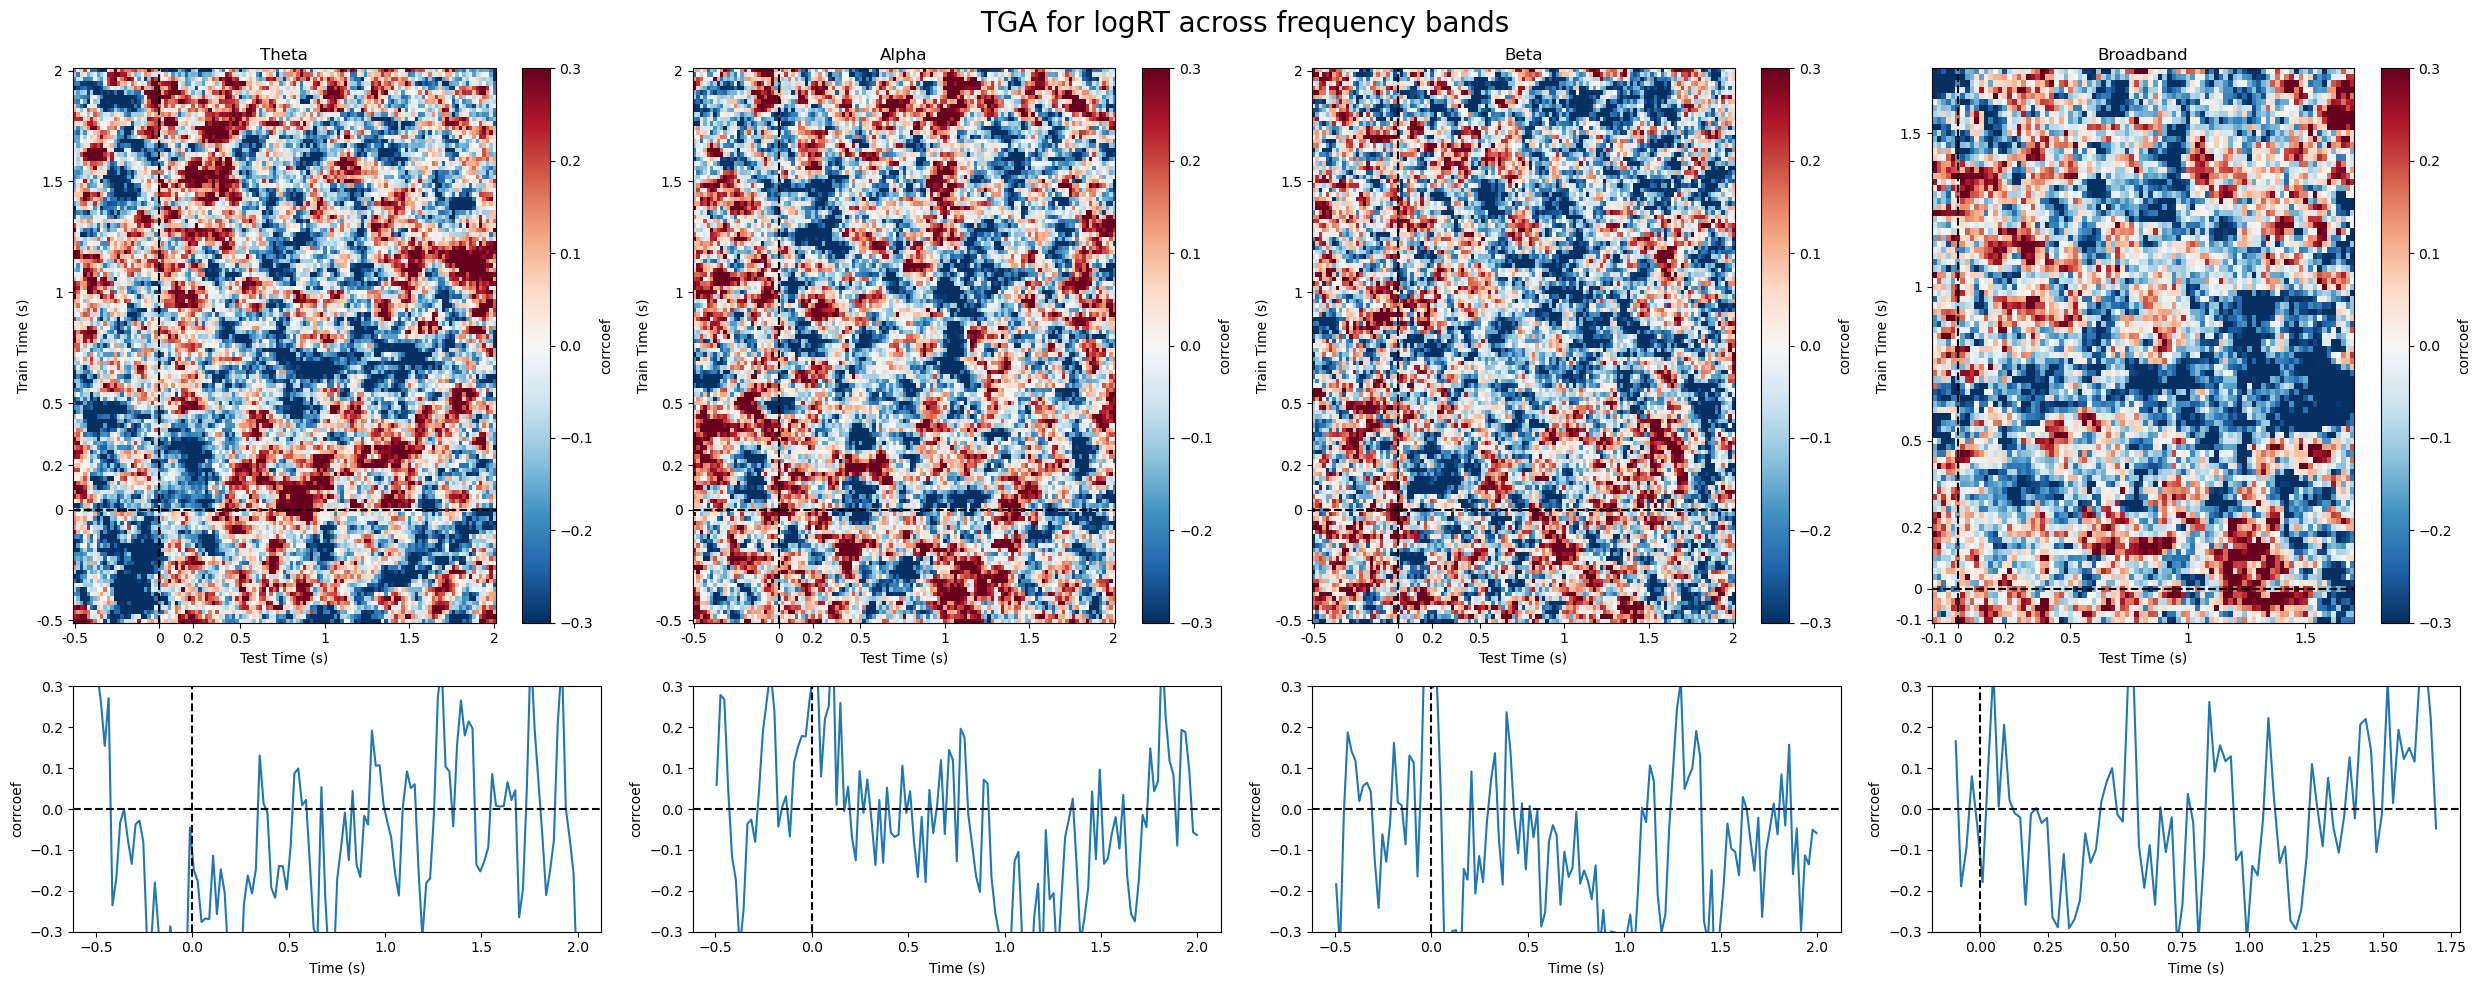

In [ ]:
time_nb = [-0.5, 0, 0.2, 0.5, 1, 1.5, 2]
time_broad = [-0.1, 0, 0.2, 0.5, 1, 1.5]
tidx_nb = [np.argmin(np.abs(timesTheta - t)) for t in time_nb]
tidx_broad = [np.argmin(np.abs(timesBroadband - t)) for t in time_broad]
# tidx_to_plot = [np.argmin(np.abs(times_crop - t)) for t in time_to_plot]

# chanceLevel = np.nanmean(np.diag(corrthetaMat.T)[:tidx_nb[1]])
chanceLevel = 0
perfLabel = 'corr'

# lowLim = chanceLevel - 0.025
# highLim = chanceLevel + 0.025
# diagLowLim = 0.14
# diagHighLim = 0.2
lowLim = -0.3
highLim = 0.3
diagLowLim = -0.3
diagHighLim = 0.3
# lowLim = 0
# highLim = 0.2
# diagLowLim = 0
# diagHighLim = 0.2
fig = plt.figure(figsize=(25, 10))
plt.suptitle('TGA for ' + behavMetric + ' across frequency bands', fontsize=20)
gs = GridSpec(3, 8, figure=fig)  
ax1 = fig.add_subplot(gs[:2, :2])
im1 = ax1.imshow(corrthetaMat, aspect='auto', origin='lower', cmap='RdBu_r', vmin=lowLim, vmax=highLim)
ax1.set_title('Theta')
ax1.set_xlabel('Test Time (s)')
ax1.set_ylabel('Train Time (s)')
ax1.set_xticks(tidx_nb)
ax1.set_xticklabels(time_nb)
ax1.set_yticks(tidx_nb)
ax1.set_yticklabels(time_nb)
ax1.axvline(tidx_nb[1], color='k', linestyle='--')
ax1.axhline(tidx_nb[1], color='k', linestyle='--')
cm1 = fig.colorbar(im1, ax=ax1)
cm1.set_label(perfLabel)

ax2 = fig.add_subplot(gs[:2, 2:4])
im2 = ax2.imshow(corralphaMat, aspect='auto', origin='lower', cmap='RdBu_r', vmin=lowLim, vmax=highLim)
ax2.set_title('Alpha')
ax2.set_xlabel('Test Time (s)')
ax2.set_ylabel('Train Time (s)')
ax2.set_xticks(tidx_nb)
ax2.set_xticklabels(time_nb)
ax2.set_yticks(tidx_nb)
ax2.set_yticklabels(time_nb)
ax2.axvline(tidx_nb[1], color='k', linestyle='--')
ax2.axhline(tidx_nb[1], color='k', linestyle='--')
cm2 = fig.colorbar(im2, ax=ax2)
cm2.set_label(perfLabel)


ax3 = fig.add_subplot(gs[:2, 4:6])
im3 = ax3.imshow(corrbetaMat, aspect='auto', origin='lower', cmap='RdBu_r', vmin=lowLim, vmax=highLim)
ax3.set_title('Beta')
ax3.set_xlabel('Test Time (s)')
ax3.set_ylabel('Train Time (s)')
ax3.set_xticks(tidx_nb)
ax3.set_xticklabels(time_nb)
ax3.set_yticks(tidx_nb)
ax3.set_yticklabels(time_nb)
ax3.axvline(tidx_nb[1], color='k', linestyle='--')
ax3.axhline(tidx_nb[1], color='k', linestyle='--')
cm3 = fig.colorbar(im3, ax=ax3)
cm3.set_label(perfLabel)

ax4 = fig.add_subplot(gs[:2, 6:])
im4=ax4.imshow(corrBroadbandMat, aspect='auto', origin='lower', cmap='RdBu_r', vmin=lowLim, vmax=highLim)
ax4.set_title('Broadband')
ax4.set_xlabel('Test Time (s)')
ax4.set_ylabel('Train Time (s)')
ax4.set_xticks(tidx_broad)
ax4.set_xticklabels(time_broad)
ax4.set_yticks(tidx_broad)
ax4.set_yticklabels(time_broad)
ax4.axvline(tidx_broad[1], color='k', linestyle='--')
ax4.axhline(tidx_broad[1], color='k', linestyle='--')
cm4 = fig.colorbar(im4, ax=ax4)
cm4.set_label(perfLabel)


# Plot diagonals at bottom
ax5 = fig.add_subplot(gs[2, :2])
ax5.plot(timesTheta, np.diag(corrthetaMat.T))
ax5.axhline(chanceLevel, color='k', linestyle='--')
ax5.axvline(x=0, color='k', linestyle='--')
ax5.set_xlabel('Time (s)')
ax5.set_ylabel(perfLabel)
ax5.set_ylim([diagLowLim, diagHighLim])

ax6 = fig.add_subplot(gs[2, 2:4])
ax6.plot(timesAlpha, np.diag(corralphaMat.T))
ax6.axhline(chanceLevel, color='k', linestyle='--')
ax6.axvline(x=0, color='k', linestyle='--')
ax6.set_xlabel('Time (s)')
ax6.set_ylabel(perfLabel)
ax6.set_ylim([diagLowLim, diagHighLim])

ax7 = fig.add_subplot(gs[2, 4:6])
ax7.plot(timesBeta, np.diag(corrbetaMat.T))
ax7.axhline(chanceLevel, color='k', linestyle='--')
ax7.axvline(x=0, color='k', linestyle='--')
ax7.set_xlabel('Time (s)')
ax7.set_ylabel(perfLabel)
ax7.set_ylim([diagLowLim, diagHighLim])

ax8 = fig.add_subplot(gs[2, 6:])
ax8.plot(timesBroadband, np.diag(corrBroadbandMat.T))
ax8.axhline(chanceLevel, color='k', linestyle='--')
ax8.axvline(x=0, color='k', linestyle='--')
ax8.set_xlabel('Time (s)')
ax8.set_ylabel(perfLabel)
ax8.set_ylim([diagLowLim, diagHighLim])
plt.tight_layout()
plt.show()

# figPath = '/d/DATD/datd/MEG_MGS/MEG_BIDS/derivatives/group_plots/temporalgeneralization_acrossbands.eps'
# plt.savefig(figPath, dpi=300, format='eps')
 

In [73]:
aa = np.diag(f1thetaMat)
print(aa.shape)

ValueError: Input must be 1- or 2-d.

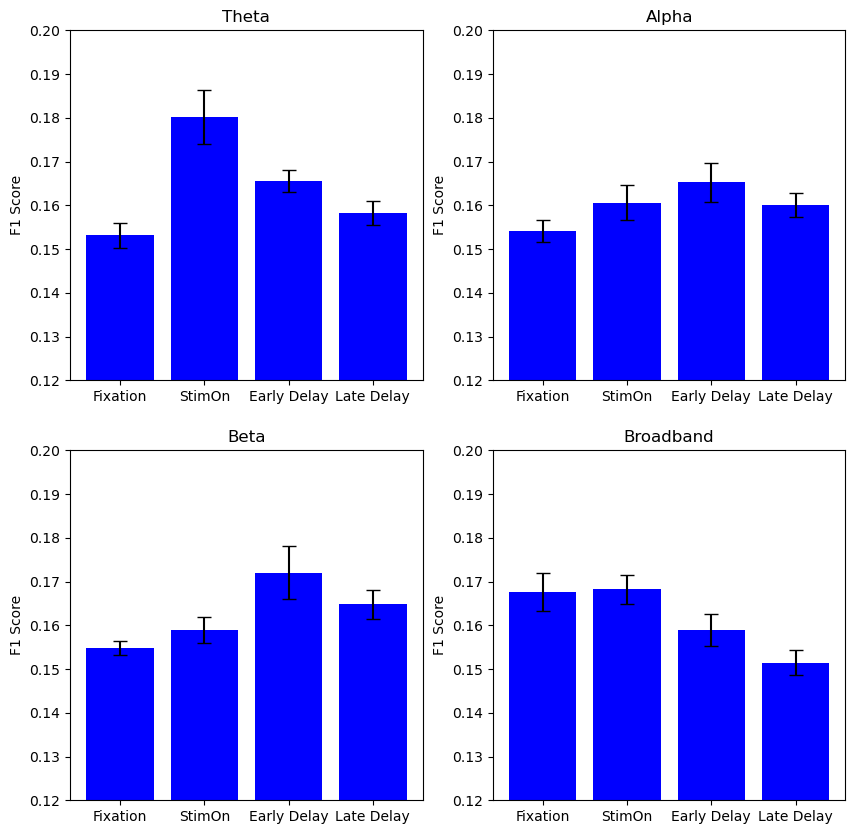

In [77]:
f, axs = plt.subplots(2, 2, figsize=(10, 10))
axs = axs.ravel()
time_epOnset = [-0.5, 0, 0.5, 1]
time_epOffset = [0, 0.3, 1, 1.5]
tidx_nb_epOnset = [np.argmin(np.abs(timesTheta - t)) for t in time_epOnset]
tidx_nb_epOffset = [np.argmin(np.abs(timesTheta - t)) for t in time_epOffset]
tidx_broad_epOnset = [np.argmin(np.abs(timesBroadband - t)) for t in time_epOnset]
tidx_broad_epOffset = [np.argmin(np.abs(timesBroadband - t)) for t in time_epOffset]
epochLabels = ['Fixation', 'StimOn', 'Early Delay', 'Late Delay']
freqLabels = ['Theta', 'Alpha', 'Beta', 'Broadband']

# Plot the theta band
for i in range(4):
    if i == 0:
        thisMat = f1thetaMat
    elif i == 1:
        thisMat = f1alphaMat
    elif i == 2:
        thisMat = f1betaMat
    else:
        thisMat = f1BroadbandMat

    # Just take the diagonal of the matrix
    decodFlattened = np.empty((len(subList), thisMat.shape[1]))
    for sIdx in range(len(subList)):
        decodFlattened[sIdx, :] = np.diag(thisMat[sIdx, :, :].T)

    decodByEpoch = np.empty((len(subList), len(time_epOnset)))
    for j in range(len(time_epOnset)):
        decodByEpoch[:, j] = np.nanmean(decodFlattened[:, tidx_nb_epOnset[j]:tidx_nb_epOffset[j]], axis=1)
    
    meanDecodByEpoch = np.nanmean(decodByEpoch, axis=0)
    semDecodByEpoch = np.nanstd(decodByEpoch, axis=0) / np.sqrt(len(subList))
    # Plot the results
    axs[i].bar([0, 1, 2, 3], meanDecodByEpoch, yerr=semDecodByEpoch, color='blue', capsize=5)
    axs[i].set_xticks([0, 1, 2, 3])
    axs[i].set_xticklabels(epochLabels)
    axs[i].set_title(freqLabels[i])
    axs[i].set_ylabel('F1 Score')
    axs[i].set_ylim([0.12, 0.2])
    # axs[i].set_title('Theta band')

plt.show()


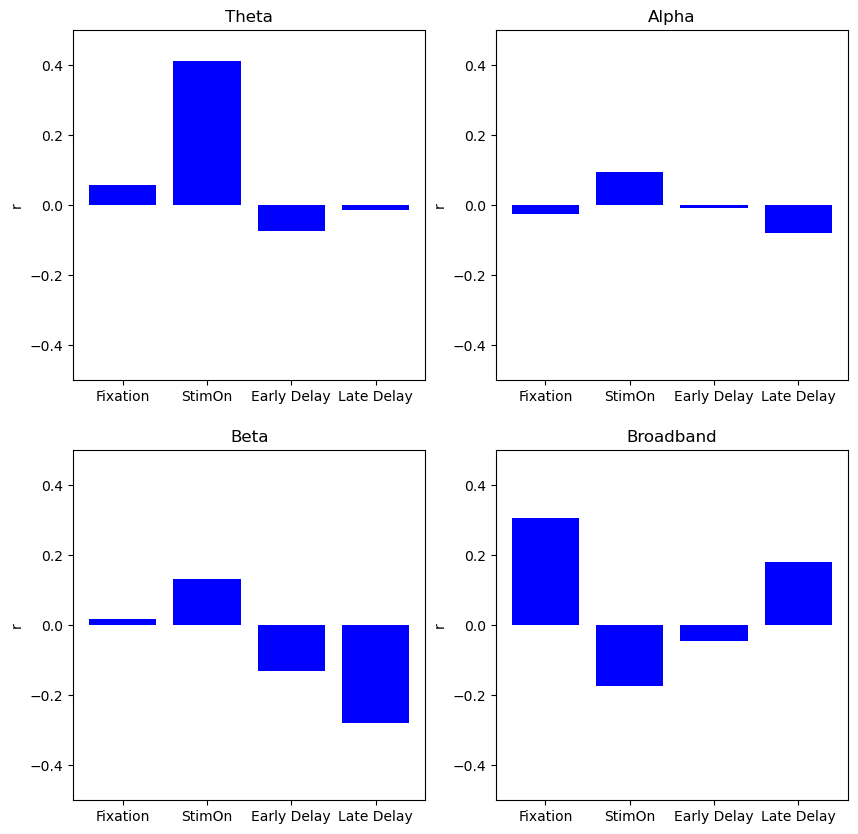

In [97]:
f, axs = plt.subplots(2, 2, figsize=(10, 10))
axs = axs.ravel()
time_epOnset = [-0.3, 0.1, 0.5, 1]
time_epOffset = [0, 0.3, 1, 1.5]
tidx_nb_epOnset = [np.argmin(np.abs(timesTheta - t)) for t in time_epOnset]
tidx_nb_epOffset = [np.argmin(np.abs(timesTheta - t)) for t in time_epOffset]
tidx_broad_epOnset = [np.argmin(np.abs(timesBroadband - t)) for t in time_epOnset]
tidx_broad_epOffset = [np.argmin(np.abs(timesBroadband - t)) for t in time_epOffset]
epochLabels = ['Fixation', 'StimOn', 'Early Delay', 'Late Delay']
freqLabels = ['Theta', 'Alpha', 'Beta', 'Broadband']
behavMetric = 'error'  # valid options: reaction_time, velocity, error
# Plot the theta band
for i in range(4):
    if i == 0:
        thisMat = f1thetaMat
    elif i == 1:
        thisMat = f1alphaMat
    elif i == 2:
        thisMat = f1betaMat
    else:
        thisMat = f1BroadbandMat

    # Just take the diagonal of the matrix
    decodFlattened = np.empty((len(subList), thisMat.shape[1]))
    for sIdx in range(len(subList)):
        decodFlattened[sIdx, :] = np.diag(thisMat[sIdx, :, :].T)

    corrByEpoch = np.empty((len(time_epOnset),))
    # issignif = np.empty((len(time_epOnset),))
    for j in range(len(time_epOnset)):
        decodThisEpoch = decodFlattened[:, tidx_nb_epOnset[j]:tidx_nb_epOffset[j]]
        corrByEpoch[j] = np.corrcoef(np.nanmean(decodThisEpoch, axis=1), df_grouped[behavMetric])[0, 1] #** 2
        # issignif[j] = 

        # decodByEpoch[:, j] = np.nanmean(decodFlattened[:, tidx_nb_epOnset[j]:tidx_nb_epOffset[j]], axis=1)
    
   
    # Plot the results
    axs[i].bar([0, 1, 2, 3], corrByEpoch, color='blue')
    axs[i].set_xticks([0, 1, 2, 3])
    axs[i].set_xticklabels(epochLabels)
    axs[i].set_title(freqLabels[i])
    axs[i].set_ylabel('r')
    axs[i].set_ylim([-0.5, 0.5])
    # axs[i].set_title('Theta band')

plt.show()


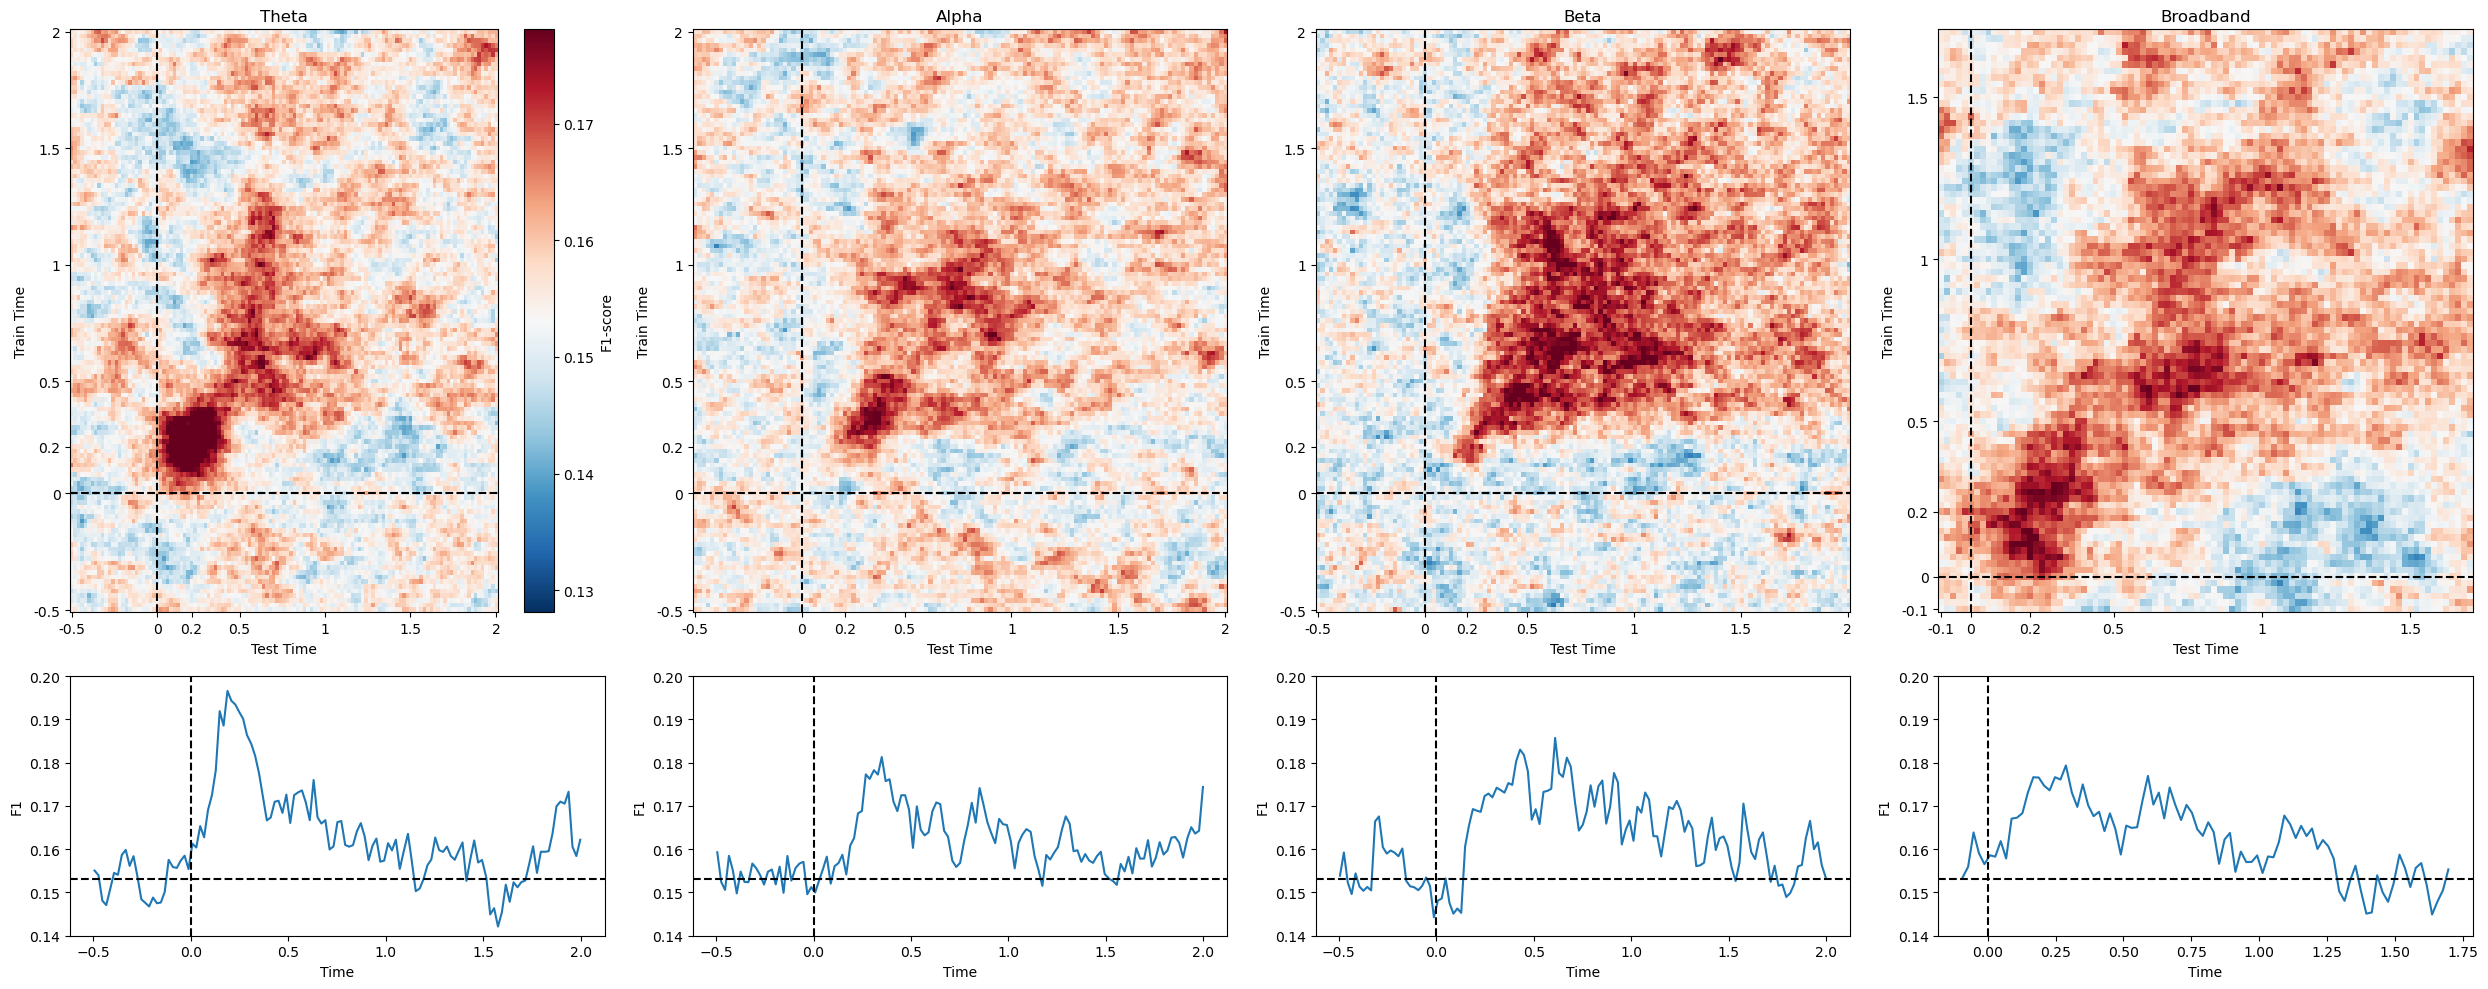

In [ ]:


time_nb = [-0.5, 0, 0.2, 0.5, 1, 1.5, 2]
time_broad = [-0.1, 0, 0.2, 0.5, 1, 1.5]
tidx_nb = [np.argmin(np.abs(timesTheta - t)) for t in time_nb]
tidx_broad = [np.argmin(np.abs(timesBroadband - t)) for t in time_broad]
# tidx_to_plot = [np.argmin(np.abs(times_crop - t)) for t in time_to_plot]

chanceLevel = np.nanmean(np.diag(f1thetaMat.T)[:tidx_nb[1]])

lowLim = chanceLevel - 0.025
highLim = chanceLevel + 0.025
diagLowLim = 0.14
diagHighLim = 0.2

fig = plt.figure(figsize=(25, 10))
gs = GridSpec(3, 8, figure=fig)  
ax1 = fig.add_subplot(gs[:2, :2])
ax1.imshow(f1thetaMat, aspect='auto', origin='lower', cmap='RdBu_r', vmin=lowLim, vmax=highLim)
ax1.set_title('Theta')
ax1.set_xlabel('Test Time')
ax1.set_ylabel('Train Time')
ax1.set_xticks(tidx_nb)
ax1.set_xticklabels(time_nb)
ax1.set_yticks(tidx_nb)
ax1.set_yticklabels(time_nb)
ax1.axvline(tidx_nb[1], color='k', linestyle='--')
ax1.axhline(tidx_nb[1], color='k', linestyle='--')

ax2 = fig.add_subplot(gs[:2, 2:4])
ax2.imshow(f1alphaMat, aspect='auto', origin='lower', cmap='RdBu_r', vmin=lowLim, vmax=highLim)
ax2.set_title('Alpha')
ax2.set_xlabel('Test Time')
ax2.set_ylabel('Train Time')
ax2.set_xticks(tidx_nb)
ax2.set_xticklabels(time_nb)
ax2.set_yticks(tidx_nb)
ax2.set_yticklabels(time_nb)
ax2.axvline(tidx_nb[1], color='k', linestyle='--')
ax2.axhline(tidx_nb[1], color='k', linestyle='--')

ax3 = fig.add_subplot(gs[:2, 4:6])
ax3.imshow(f1betaMat, aspect='auto', origin='lower', cmap='RdBu_r', vmin=lowLim, vmax=highLim)
ax3.set_title('Beta')
ax3.set_xlabel('Test Time')
ax3.set_ylabel('Train Time')
ax3.set_xticks(tidx_nb)
ax3.set_xticklabels(time_nb)
ax3.set_yticks(tidx_nb)
ax3.set_yticklabels(time_nb)
ax3.axvline(tidx_nb[1], color='k', linestyle='--')
ax3.axhline(tidx_nb[1], color='k', linestyle='--')

ax4 = fig.add_subplot(gs[:2, 6:])
im=ax4.imshow(f1BroadbandMat, aspect='auto', origin='lower', cmap='RdBu_r', vmin=lowLim, vmax=highLim)
ax4.set_title('Broadband')
ax4.set_xlabel('Test Time')
ax4.set_ylabel('Train Time')
ax4.set_xticks(tidx_broad)
ax4.set_xticklabels(time_broad)
ax4.set_yticks(tidx_broad)
ax4.set_yticklabels(time_broad)
ax4.axvline(tidx_broad[1], color='k', linestyle='--')
ax4.axhline(tidx_broad[1], color='k', linestyle='--')
cm = fig.colorbar(im, ax=ax1)
cm.set_label('F1-score')

# Plot diagonals at bottom
ax5 = fig.add_subplot(gs[2, :2])
ax5.plot(timesTheta, np.diag(f1thetaMat.T))
ax5.axhline(chanceLevel, color='k', linestyle='--')
ax5.axvline(x=0, color='k', linestyle='--')
ax5.set_xlabel('Time')
ax5.set_ylabel('F1')
ax5.set_ylim([diagLowLim, diagHighLim])

ax6 = fig.add_subplot(gs[2, 2:4])
ax6.plot(timesAlpha, np.diag(f1alphaMat.T))
ax6.axhline(chanceLevel, color='k', linestyle='--')
ax6.axvline(x=0, color='k', linestyle='--')
ax6.set_xlabel('Time')
ax6.set_ylabel('F1')
ax6.set_ylim([diagLowLim, diagHighLim])

ax7 = fig.add_subplot(gs[2, 4:6])
ax7.plot(timesBeta, np.diag(f1betaMat.T))
ax7.axhline(chanceLevel, color='k', linestyle='--')
ax7.axvline(x=0, color='k', linestyle='--')
ax7.set_xlabel('Time')
ax7.set_ylabel('F1')
ax7.set_ylim([diagLowLim, diagHighLim])

ax8 = fig.add_subplot(gs[2, 6:])
ax8.plot(timesBroadband, np.diag(f1BroadbandMat.T))
ax8.axhline(chanceLevel, color='k', linestyle='--')
ax8.axvline(x=0, color='k', linestyle='--')
ax8.set_xlabel('Time')
ax8.set_ylabel('F1')
ax8.set_ylim([diagLowLim, diagHighLim])
plt.tight_layout()
# plt.show()

figPath = '/d/DATD/datd/MEG_MGS/MEG_BIDS/derivatives/group_plots/temporalgeneralization_acrossbands.eps'
plt.savefig(figPath, dpi=300, format='eps')
 # Plot the accuracy matrix
   
        
    
    # # Identify the lower and upper bounds for the colorbar
    # qtThresh = 0.0005
    # # xLowAuc = np.quantile(auc_matrix, qtThresh)
    # # yLowAuc = np.quantile(auc_matrix, 1 - qtThresh)
    # xLowAuc = np.quantile(f1_matrix, qtThresh)
    # yLowAuc = np.quantile(f1_matrix, 1 - qtThresh)
    # # Plot the accuracy matrix
    # fig = plt.figure(figsize=(10, 10))
    
    # gs = GridSpec(3, 2, figure=fig)  
    # # Accuracy matrix plot (0, 0)
    # ax1 = fig.add_subplot(gs[:2, :])  
    # # im = ax1.imshow(auc_matrix, aspect='auto', origin='lower', cmap='RdBu_r', vmin=xLowAuc, vmax=yLowAuc)
    # im = ax1.imshow(f1_matrix, aspect='auto', origin='lower', cmap='RdBu_r', vmin=xLowAuc, vmax=yLowAuc)
    # # ax1.set_title('ROC-AUC')
    # ax1.set_xlabel('Test Time')
    # ax1.set_ylabel('Train Time')
    # ax1.set_xticks(tidx_to_plot)
    # ax1.set_xticklabels(time_to_plot)
    # ax1.set_yticks(tidx_to_plot)
    # ax1.set_yticklabels(time_to_plot)
    # ax1.axvline(tidx_to_plot[1], color='k', linestyle='--')
    # ax1.axhline(tidx_to_plot[1], color='k', linestyle='--')
    # cm = fig.colorbar(im, ax=ax1)
    # # cm.set_label('ROC-AUC')
    # cm.set_label('F1')

    # # Plot mean accuracy along diagonal (0, 1)
    # ax3 = fig.add_subplot(gs[2, :])
    # # ax3.plot(times_crop, np.diag(auc_matrix.T))
    # ax3.plot(times_crop, np.diag(f1_matrix.T))
    # ax3.plot(times_crop, np.diag(f1_chance_matrix.T), linestyle='--')
    # # ax3.set_title('ROC-AUC Diagonal')
    # ax3.set_title('F1 Diagonal')
    # ax3.set_xlabel('Time')
    # # ax3.set_ylabel('ROC-AUC')
    # ax3.set_ylabel('F1')
    # # ax3.axhline(0.5, color='k', linestyle='--')
    # ax3.set_ylim([xLowAuc, yLowAuc])
    
    # plt.tight_layout()
    # # plt.suptitle('Decoding Performance: ' + classifType + ' ' + freqband)
    # if powOphase == 'power':
    #     figPath = os.path.join(figDir, 'group_' + classifType + '_' + freqband + '_lineremoved.png')
    # else:
    #     figPath = os.path.join(figDir, 'group_' + classifType + '_' + freqband + '_phase.png')
    # plt.savefig(figPath, dpi=300)
    # # plt.show()


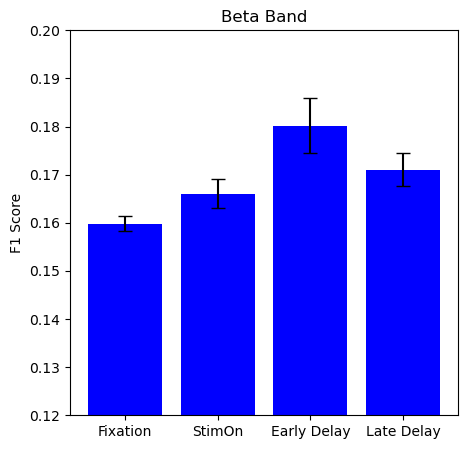

In [5]:
# f, axs = plt.subplots(1, 1, figsize=(5, 5))
plt.figure(figsize=(5, 5))
# axs = axs.ravel()
time_epOnset = [-0.5, 0, 0.5, 1]
time_epOffset = [0, 0.3, 1, 1.5]
tidx_nb_epOnset = [np.argmin(np.abs(timesBeta - t)) for t in time_epOnset]
tidx_nb_epOffset = [np.argmin(np.abs(timesBeta - t)) for t in time_epOffset]
# tidx_broad_epOnset = [np.argmin(np.abs(timesBroadband - t)) for t in time_epOnset]
# tidx_broad_epOffset = [np.argmin(np.abs(timesBroadband - t)) for t in time_epOffset]
epochLabels = ['Fixation', 'StimOn', 'Early Delay', 'Late Delay']
freqLabels = ['Theta', 'Alpha', 'Beta', 'Broadband']

# Plot the theta band
# for i in range(:
    
i = 0
thisMat = f1betaMat


# Just take the diagonal of the matrix
decodFlattened = np.empty((len(subList), thisMat.shape[1]))
for sIdx in range(len(subList)):
    decodFlattened[sIdx, :] = np.diag(thisMat[sIdx, :, :].T)

decodByEpoch = np.empty((len(subList), len(time_epOnset)))
for j in range(len(time_epOnset)):
    decodByEpoch[:, j] = np.nanmean(decodFlattened[:, tidx_nb_epOnset[j]:tidx_nb_epOffset[j]], axis=1)

meanDecodByEpoch = np.nanmean(decodByEpoch, axis=0)
semDecodByEpoch = np.nanstd(decodByEpoch, axis=0) / np.sqrt(len(subList))
# Plot the results
plt.bar([0, 1, 2, 3], meanDecodByEpoch, yerr=semDecodByEpoch, color='blue', capsize=5)
plt.xticks([0, 1, 2, 3], epochLabels)
plt.title('Beta Band')
plt.ylabel('F1 Score')
plt.ylim([0.12, 0.2])

# axs[i].bar([0, 1, 2, 3], meanDecodByEpoch, yerr=semDecodByEpoch, color='blue', capsize=5)
# axs[i].set_xticks([0, 1, 2, 3])
# axs[i].set_xticklabels(epochLabels)
# axs[i].set_title(freqLabels[i])
# axs[i].set_ylabel('F1 Score')
# axs[i].set_ylim([0.12, 0.2])
# axs[i].set_title('Theta band')

plt.show()


<Figure size 500x500 with 0 Axes>

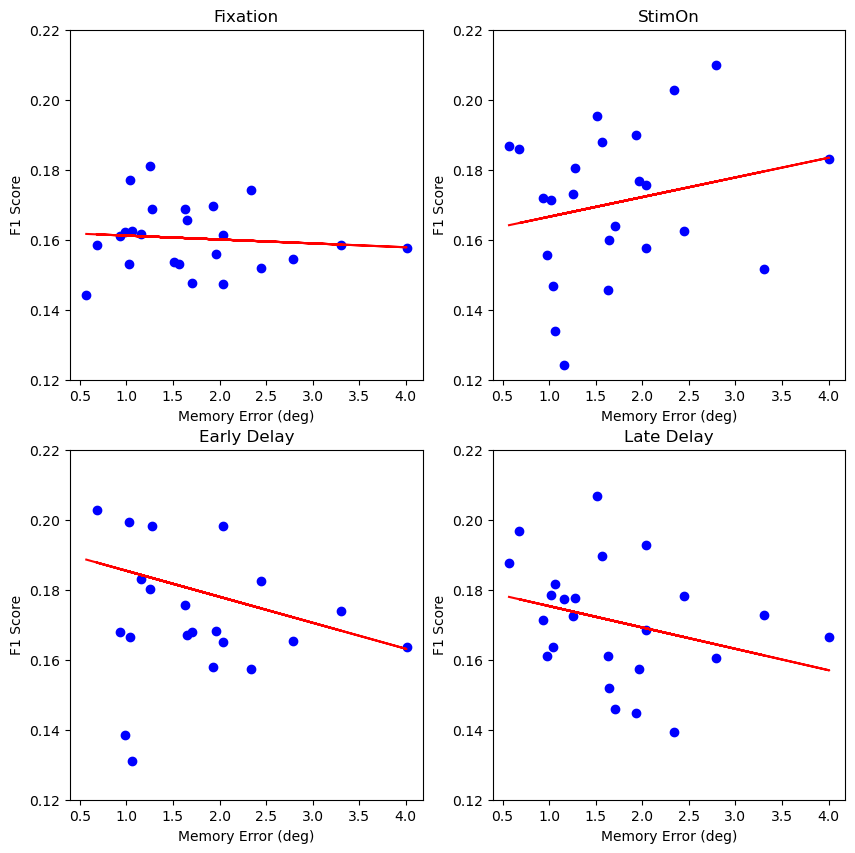

In [23]:
# f, axs = plt.subplots(2, 2, figsize=(10, 10))
plt.figure(figsize=(5, 5))

# axs = axs.ravel()
time_epOnset = [-0.3, 0.1, 0.5, 1]
time_epOffset = [0, 0.3, 1, 1.5]
tidx_nb_epOnset = [np.argmin(np.abs(timesBeta - t)) for t in time_epOnset]
tidx_nb_epOffset = [np.argmin(np.abs(timesBeta - t)) for t in time_epOffset]

epochLabels = ['Fixation', 'StimOn', 'Early Delay', 'Late Delay']
freqLabels = ['Theta', 'Alpha', 'Beta', 'Broadband']
behavMetric = 'error'  # valid options: reaction_time, velocity, error
# Plot the theta band

thisMat = f1betaMat


# Just take the diagonal of the matrix
decodFlattened = np.empty((len(subList), thisMat.shape[1]))
for sIdx in range(len(subList)):
    decodFlattened[sIdx, :] = np.diag(thisMat[sIdx, :, :].T)

corrByEpoch = np.empty((len(time_epOnset),))
# issignif = np.empty((len(time_epOnset),))
for j in range(len(time_epOnset)):
    decodThisEpoch = decodFlattened[:, tidx_nb_epOnset[j]:tidx_nb_epOffset[j]]
    corrByEpoch[j] = np.corrcoef(np.nanmean(decodThisEpoch, axis=1), df_grouped[behavMetric])[0, 1] #** 2
    # issignif[j] = 

    # decodByEpoch[:, j] = np.nanmean(decodFlattened[:, tidx_nb_epOnset[j]:tidx_nb_epOffset[j]], axis=1)


# Plot the results
f, axs = plt.subplots(2, 2, figsize=(10, 10))
axs = axs.ravel()
for i in range(len(time_epOnset)):
    x_this = df_grouped[behavMetric]
    y_this = np.nanmean(decodFlattened[:, tidx_nb_epOnset[i]:tidx_nb_epOffset[i]], axis=1)
    # Compute regression line
    slope, intercept = np.polyfit(x_this, y_this, 1)
    axs[i].scatter(x_this, y_this, color='blue')
    axs[i].plot(x_this, slope * x_this + intercept, color='red')
    # axs[i].axhline(chanceLevel, color='k', linestyle='--')
    axs[i].set_xlabel('Memory Error (deg)')
    axs[i].set_ylabel('F1 Score')
    axs[i].set_title(epochLabels[i])
    axs[i].set_ylim([0.12, 0.22])
# axs[0].scatter(df_grouped[behavMetric], decodFlattened[:, 0], color='blue')
# axs[0].set_xlabel('Behavior')
# axs[0].set_ylabel('Decoding')

# plt.bar([0, 1, 2, 3], corrByEpoch, color='blue')
# plt.xticks([0, 1, 2, 3], epochLabels)
# plt.title('Beta Band')
# plt.ylabel('r')
# plt.ylim([-0.4, 0.4])

# axs[i].bar([0, 1, 2, 3], corrByEpoch, color='blue')
# axs[i].set_xticks([0, 1, 2, 3])
# axs[i].set_xticklabels(epochLabels)
# axs[i].set_title(freqLabels[i])
# axs[i].set_ylabel('r')
# axs[i].set_ylim([-0.5, 0.5])
# axs[i].set_title('Theta band')
# plt.savefig('beta_cohwithBehav.svg', dpi=300, format='svg')
plt.show()


In [15]:
def run_subject_forPerf(subjID, bidsRoot, taskName, classifName, classifType, freqband, powOphase):
    subName = 'sub-%02d' % subjID
    print('Running classification for ' + subName)
    # derivativesRoot = os.path.join(bidsRoot, 'derivatives', subName, 'meg')
    derivativesRoot = os.path.join(bidsRoot, 'derivatives', subName)
    eyeRoot = os.path.join(derivativesRoot, 'eyetracking')
    megRoot = os.path.join(derivativesRoot, 'meg')
    fNameRoot = subName + '_task-' + taskName
    iisess_fpath = os.path.join(eyeRoot, fNameRoot + '-iisess.mat')
    stimLocked_fpath = os.path.join(megRoot, fNameRoot + '_stimlocked_lineremoved.mat')
    stimRoot = os.path.join(bidsRoot, subName, 'stimfiles')
    
    if powOphase == 'power':
        TFR_fpath = os.path.join(megRoot, fNameRoot + '_TFR_evoked_lineremoved.mat')
    else:
        TFR_fpath = os.path.join(megRoot, fNameRoot + '_TFR_phase.mat')
    classifHolderRoot = os.path.join(megRoot, 'decodingByPerf_lineremoved')
    if not os.path.exists(classifHolderRoot):
        os.mkdir(classifHolderRoot)

    classifPath = os.path.join(classifHolderRoot, classifName)

    if os.path.exists(classifPath):
        # Load the classifier
        print('Loading existing classifier performance')
        with open(classifPath, 'rb') as f:
            classifData = pickle.load(f)
        f1_matrix_highPerf = classifData['f1_matrix_highPerf']
        f1_chance_matrix_highPerf = classifData['f1_chance_matrix_highPerf']
        f1_matrix_lowPerf = classifData['f1_matrix_lowPerf']
        f1_chance_matrix_lowPerf = classifData['f1_chance_matrix_lowPerf']
        times_crop = classifData['times_crop']
    
    return subjID, f1_matrix_highPerf, f1_chance_matrix_highPerf, f1_matrix_lowPerf, f1_chance_matrix_lowPerf, times_crop


def extractTGA_forPerf(freqband):
    
    subList = [1, 2, 3, 4, 5, 6, 7, 9, 10, 12, 13, 15, 17, 
               18, 19, 23, 24, 25, 26, 27, 28, 29, 31, 32]

    # freqband = 'broadband' # valid options: alpha, beta, broadband
    powOphase = 'power' # valid options: power, phase
    classifType = 'quadrant' # valid options: hemifield, quadrant, locGroups, indivTargets
    classifName = 'classif_' + classifType + '_' + freqband + '.pkl'
    
    if freqband == 'broadband':
        ntimePts = 90
    else:
        ntimePts = 125
    f1MatHighPerf = np.empty((len(subList), ntimePts, ntimePts))
    f1ChanceMatHighPerf = np.empty((len(subList), ntimePts, ntimePts))
    f1MatLowPerf = np.empty((len(subList), ntimePts, ntimePts))
    f1ChanceMatLowPerf = np.empty((len(subList), ntimePts, ntimePts))

    bidsRoot = '/System/Volumes/Data/d/DATD/datd/MEG_MGS/MEG_BIDS'
   
    taskName = 'mgs'
    figDir = os.path.join(bidsRoot, 'derivatives', 'group_plots')
    if not os.path.exists(figDir):
        os.mkdir(figDir)

    # Run without parallelization
    for sIdx, subjID in enumerate(subList):
        res = run_subject_forPerf(subjID, bidsRoot, taskName, classifName, classifType, freqband, powOphase)
        # aucMat[sIdx, :, :], times_crop = res[1], res[2]#, res[3], res[4]
        f1MatHighPerf[sIdx, :, :], f1ChanceMatHighPerf[sIdx, :, :], f1MatLowPerf[sIdx, :, :], f1ChanceMatLowPerf[sIdx, :, :], times_crop = res[1], res[2], res[3], res[4], res[5]
    # Average the accuracy and f1score matrices
    # f1_matrix = np.nanmean(f1Mat, axis=0)
    # f1_chance_matrix = np.nanmean(f1ChanceMat, axis=0)

    # return f1_matrix, times_crop
    return f1MatHighPerf, f1ChanceMatHighPerf, f1MatLowPerf, f1ChanceMatLowPerf, times_crop

In [16]:
f1MatHighPerf, f1ChanceMatHighPerf, f1MatLowPerf, f1ChanceMatLowPerf, times_crop = extractTGA_forPerf('beta')

Running classification for sub-01
Loading existing classifier performance
Running classification for sub-02
Loading existing classifier performance
Running classification for sub-03
Loading existing classifier performance
Running classification for sub-04
Loading existing classifier performance
Running classification for sub-05
Loading existing classifier performance
Running classification for sub-06
Loading existing classifier performance
Running classification for sub-07
Loading existing classifier performance
Running classification for sub-09
Loading existing classifier performance
Running classification for sub-10
Loading existing classifier performance
Running classification for sub-12
Loading existing classifier performance
Running classification for sub-13
Loading existing classifier performance
Running classification for sub-15
Loading existing classifier performance
Running classification for sub-17
Loading existing classifier performance
Running classification for sub-18
Load

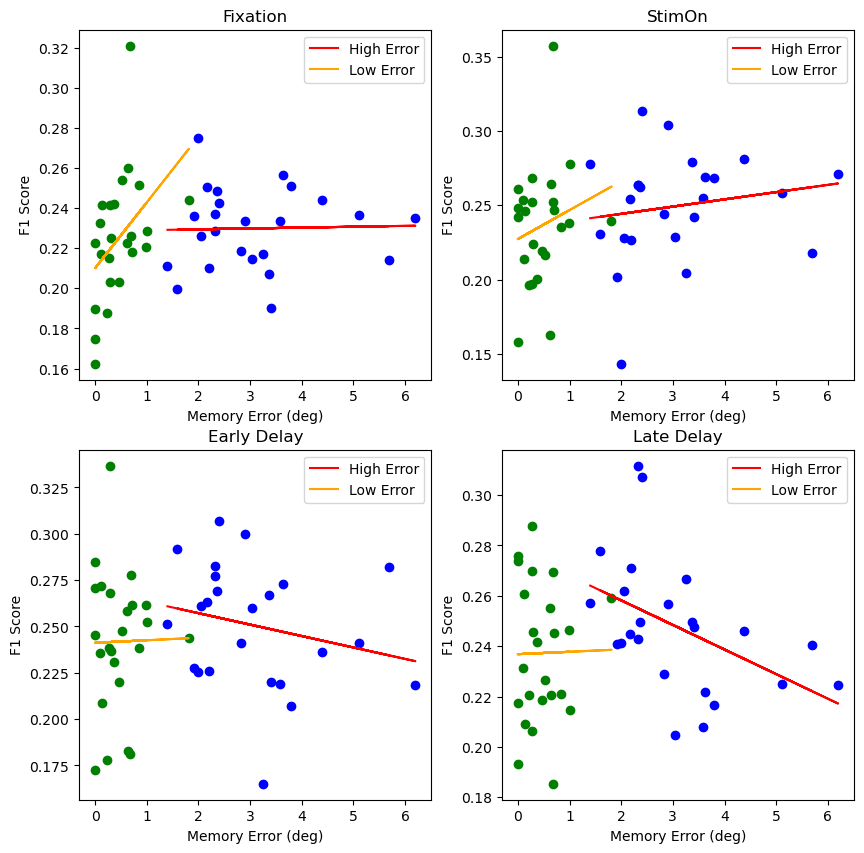

In [21]:
# f, axs = plt.subplots(2, 2, figsize=(10, 10))
# axs = axs.ravel()
time_epOnset = [-0.3, 0.1, 0.5, 1]
time_epOffset = [0, 0.3, 1, 1.5]
tidx_nb_epOnset = [np.argmin(np.abs(timesBeta - t)) for t in time_epOnset]
tidx_nb_epOffset = [np.argmin(np.abs(timesBeta - t)) for t in time_epOffset]

epochLabels = ['Fixation', 'StimOn', 'Early Delay', 'Late Delay']
freqLabels = ['Theta', 'Alpha', 'Beta', 'Broadband']
behavMetric = 'error'  # valid options: reaction_time, velocity, error
# Plot the theta band

thisMatHighPerf = f1MatHighPerf
thisMatLowPerf = f1MatLowPerf

decodFlattenedHighPerf = np.empty((len(subList), thisMatHighPerf.shape[1]))
decodFlattenedLowPerf = np.empty((len(subList), thisMatLowPerf.shape[1]))
for sIdx in range(len(subList)):
    decodFlattenedHighPerf[sIdx, :] = np.diag(thisMatHighPerf[sIdx, :, :].T)
    decodFlattenedLowPerf[sIdx, :] = np.diag(thisMatLowPerf[sIdx, :, :].T)
corrByEpochHighPerf = np.empty((len(time_epOnset),))
corrByEpochLowPerf = np.empty((len(time_epOnset),))

for j in range(len(time_epOnset)):
    decodThisEpochHighPerf = decodFlattenedHighPerf[:, tidx_nb_epOnset[j]:tidx_nb_epOffset[j]]
    decodThisEpochLowPerf = decodFlattenedLowPerf[:, tidx_nb_epOnset[j]:tidx_nb_epOffset[j]]
    corrByEpochHighPerf[j] = np.corrcoef(np.nanmean(decodThisEpochHighPerf, axis=1), df_grouped[behavMetric])[0, 1] #** 2
    corrByEpochLowPerf[j] = np.corrcoef(np.nanmean(decodThisEpochLowPerf, axis=1), df_grouped[behavMetric])[0, 1] #** 2

# Plot the results
f, axs = plt.subplots(2, 2, figsize=(10, 10))
axs = axs.ravel()
for i in range(len(time_epOnset)):
    # x_this = df_grouped[behavMetric]
    x_thisHighPerf = df_grouped_highPerf[behavMetric]
    x_thisLowPerf = df_grouped_lowPerf[behavMetric]
    y_thisHighPerf = np.nanmean(decodFlattenedHighPerf[:, tidx_nb_epOnset[i]:tidx_nb_epOffset[i]], axis=1)
    y_thisLowPerf = np.nanmean(decodFlattenedLowPerf[:, tidx_nb_epOnset[i]:tidx_nb_epOffset[i]], axis=1)
    # Compute regression line
    slope, intercept = np.polyfit(x_thisHighPerf, y_thisHighPerf, 1)
    axs[i].scatter(x_thisHighPerf, y_thisHighPerf, color='blue')
    axs[i].plot(x_thisHighPerf, slope * x_thisHighPerf + intercept, color='red', label='High Error')
    slope, intercept = np.polyfit(x_thisLowPerf, y_thisLowPerf, 1)
    axs[i].scatter(x_thisLowPerf, y_thisLowPerf, color='green')
    axs[i].plot(x_thisLowPerf, slope * x_thisLowPerf + intercept, color='orange', label='Low Error')
    axs[i].legend()
    # axs[i].axhline(chanceLevel, color='k', linestyle='--')
    axs[i].set_xlabel('Memory Error (deg)')
    axs[i].set_ylabel('F1 Score')
    axs[i].set_title(epochLabels[i])
    # axs[i].set_ylim([0.12, 0.22])
# axs[0].scatter(df_grouped[behavMetric], decodFlattened[:, 0], color='blue')


plt.show()


### Trial-wise decoding approx.

In [267]:
import os, pickle, h5py, socket
import numpy as np
from scipy.io import loadmat
from decodingFuncs import runMultiClassClassification
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from shutil import copyfile
from joblib import Parallel, delayed
from multiprocessing import Pool, cpu_count
import gc

def run_subject(subjID, bidsRoot, taskName, classifName, classifType, freqband, powOphase):
    subName = 'sub-%02d' % subjID
    print('Running classification for ' + subName)
    derivativesRoot = os.path.join(bidsRoot, 'derivatives', subName, 'meg')
    stimRoot = os.path.join(bidsRoot, subName, 'stimfiles')
    fNameRoot = subName + '_task-' + taskName
    if powOphase == 'power':
        TFR_fpath = os.path.join(derivativesRoot, fNameRoot + '_TFR_evoked_lineremoved.mat')
    else:
        TFR_fpath = os.path.join(derivativesRoot, fNameRoot + '_TFR_phase.mat')
    classifHolderRoot = os.path.join(derivativesRoot, 'decoding_trialwise')
    if not os.path.exists(classifHolderRoot):
        os.mkdir(classifHolderRoot)

    classifPath = os.path.join(classifHolderRoot, classifName)

    if os.path.exists(classifPath):
        # Load the classifier
        print('Loading existing classifier performance')
        with open(classifPath, 'rb') as f:
            classifData = pickle.load(f)
        # aucMatrix = classifData['auc_matrix']
        f1Matrix = classifData['f1_matrix']
        f1ChanceMatrix = classifData['f1_chance_matrix']
        trlWiseDecoding = classifData['trlWiseDecoding']
        performance = classifData['performance']
        yLabels = classifData['yLabels']
        times_crop = classifData['times_crop']
    
    return subjID, f1Matrix, f1ChanceMatrix, trlWiseDecoding, performance, yLabels, times_crop


def extractTGA(freqband):
    
    subList = [1, 2, 3, 4, 5, 6, 7, 9, 10, 12, 13, 15, 17, 
               18, 19, 23, 24, 25, 26, 27, 28, 29, 31, 32]
    # subList = [1, 2, 3, 4, 5, 6, 7, 9, 10, 12, 13, 15, 17]
    # subList = [1, 2, 3, 4, 5, 6, 7, 9, 10, 12, 13, 15]

    # freqband = 'broadband' # valid options: alpha, beta, broadband
    powOphase = 'power' # valid options: power, phase
    classifType = 'indivTargets' # valid options: hemifield, quadrant, locGroups, indivTargets
    classifName = 'classif_' + classifType + '_' + freqband + '.pkl'
    
    if freqband == 'broadband':
        ntimePts = 90
    else:
        ntimePts = 125
    f1Mat = np.empty((len(subList), ntimePts, ntimePts))
    f1ChanceMat = np.empty((len(subList), ntimePts, ntimePts))
    trlDecodMat = np.empty((len(subList), 10000, ntimePts, ntimePts))
    perfMat = np.empty((len(subList), 10000))
    trlCounter = np.empty((len(subList)))
    yLabelMat = np.empty((len(subList), 10000), dtype=object)

    bidsRoot = '/System/Volumes/Data/d/DATD/datd/MEG_MGS/MEG_BIDS'
   
    taskName = 'mgs'
    figDir = os.path.join(bidsRoot, 'derivatives', 'group_plots')
    if not os.path.exists(figDir):
        os.mkdir(figDir)

    # Run without parallelization
    for sIdx, subjID in enumerate(subList):
        res = run_subject(subjID, bidsRoot, taskName, classifName, classifType, freqband, powOphase)
        # aucMat[sIdx, :, :], times_crop = res[1], res[2]#, res[3], res[4]
        # f1Mat[sIdx, :, :], f1ChanceMat[sIdx, :, :], times_crop = res[1], res[2], res[3]
        f1Mat[sIdx, :, :], f1ChanceMat[sIdx, :, :], trlWiseDecoding, perfThisSub, yLabelsThisSub, times_crop = res[1], res[2], res[3], res[4], res[5], res[6]
        ntrlsThisSub = trlWiseDecoding.shape[0]
        trlCounter[sIdx] = ntrlsThisSub
        trlDecodMat[sIdx, :ntrlsThisSub, :, :] = trlWiseDecoding
        perfMat[sIdx, :ntrlsThisSub] = perfThisSub
        yLabelMat[sIdx, :ntrlsThisSub] = yLabelsThisSub
    # Average the accuracy and f1score matrices
    # f1_matrix = np.nanmean(f1Mat, axis=0)
    # f1_chance_matrix = np.nanmean(f1ChanceMat, axis=0)

    # return f1_matrix, times_crop
    return f1Mat, trlDecodMat, perfMat, times_crop, trlCounter, yLabelMat

In [268]:
f1betaMat, trlDecodMat, perfMat, timesBeta, trlCounter, yLabelMat = extractTGA('beta')

Running classification for sub-01
Loading existing classifier performance
Running classification for sub-02
Loading existing classifier performance
Running classification for sub-03
Loading existing classifier performance
Running classification for sub-04
Loading existing classifier performance
Running classification for sub-05
Loading existing classifier performance
Running classification for sub-06
Loading existing classifier performance
Running classification for sub-07
Loading existing classifier performance
Running classification for sub-09
Loading existing classifier performance
Running classification for sub-10
Loading existing classifier performance
Running classification for sub-12
Loading existing classifier performance
Running classification for sub-13
Loading existing classifier performance
Running classification for sub-15
Loading existing classifier performance
Running classification for sub-17
Loading existing classifier performance
Running classification for sub-18
Load

In [269]:
from scipy.stats import circmean, circstd
time_epOnset = [-0.3, 0.1, 0.5, 1]
time_epOffset = [0, 0.3, 1, 1.5]
tidx_nb_epOnset = [np.argmin(np.abs(timesBeta - t)) for t in time_epOnset]
tidx_nb_epOffset = [np.argmin(np.abs(timesBeta - t)) for t in time_epOffset]

epochLabels = ['Fixation', 'StimOn', 'Early Delay', 'Late Delay']
behavMetric = 'error'  # valid options: reaction_time, velocity, error
subList = [1, 2, 3, 4, 5, 6, 7, 9, 10, 12, 13, 15, 17, 
               18, 19, 23, 24, 25, 26, 27, 28, 29, 31, 32]
# subList = [1, 2, 3, 4, 5, 6, 7, 9]
nBins = 4
# meanErrByBin = np.empty((len(subList), len(time_epOnset), nBins))
# meanDecodByBin = np.empty((len(subList), len(time_epOnset), nBins))
# class_angles = np.array([0, 37.5, 142.5, 180, 217.5, 322.5])
class_angles = np.array([0, 25, 50, 130, 155, 180, 205, 230, 310, 335])

predBySub = np.empty((len(subList), trlDecodMat.shape[2]))
predBySubByBin = np.empty((len(subList), nBins, trlDecodMat.shape[2]))

for sIdx in range(len(subList)):
    nTrlsInitial = trlCounter[sIdx].astype(int)
    nTpoints = trlDecodMat.shape[2]
    behavPerf = perfMat[sIdx, :nTrlsInitial]
    # Find trls with behavPerf > 0.01
    goodTrls = np.where(behavPerf > 0.01)[0]
    nTrls = len(goodTrls)
    # print('Subject %d: %d trials' % (sIdx, nTrls))
    behavPerfGood = behavPerf[goodTrls]
    trlDecodMatGood = trlDecodMat[sIdx, goodTrls, :, :]
    yLabelMatGood = yLabelMat[sIdx, goodTrls]-1
    # Divide into quantiles
    bin_edges = np.percentile(behavPerfGood, np.linspace(0, 100, nBins+1))
    # bin_edges = np.concatenate(([np.min(behavPerfGood)], bin_edges, [np.max(behavPerfGood)]))
    # print(bin_edges)
    prediction_error = np.empty((nTrls, nTpoints))

    for trlIdx in range(nTrls):
        predicted_classes = np.diag(trlDecodMatGood[trlIdx, :, :].T).astype(int)
        # Get actual class for this trial
        actual_class = yLabelMatGood[trlIdx]         
        # Convert to angles
        pred_angles = class_angles[predicted_classes]
        actual_angle = class_angles[actual_class]
        
        # Calculate circular error
        ang_diff = pred_angles - actual_angle
        ang_diff = ((ang_diff + 180) % 360) - 180
        prediction_error[trlIdx, :] = ang_diff
        predBySub[sIdx, :] = circmean(prediction_error, high=-180, low=180, axis=0)

    # Compute mean error by bin for each trial
    for binIdx in range(nBins):
        # if binIdx == 0:
        #     bin_mask = behavPerfGood < bin_edges[binIdx]
        # elif binIdx == nBins - 1:
        #     bin_mask = behavPerfGood >= bin_edges[binIdx-1]
        # else:
        bin_mask = (behavPerfGood >= bin_edges[binIdx]) & (behavPerfGood < bin_edges[binIdx+1])
        # print(binIdx,     sum(bin_mask ))
        predBySubByBin[sIdx, binIdx, :] = circmean(prediction_error[bin_mask, :], high=-180, low=180, axis=0)

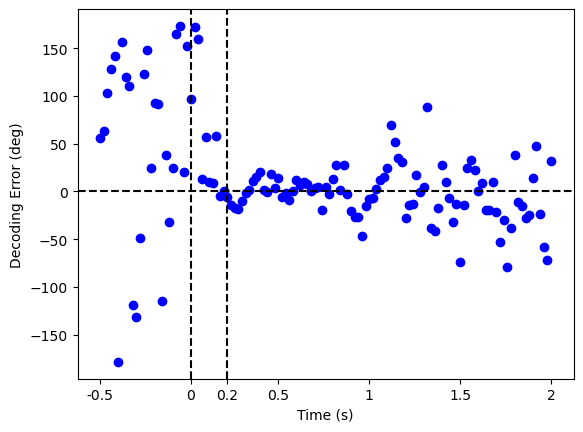

In [270]:
time_nb = [-0.5, 0, 0.2, 0.5, 1, 1.5, 2]
time_broad = [-0.1, 0, 0.2, 0.5, 1, 1.5]
tidx_nb = [np.argmin(np.abs(timesBeta - t)) for t in time_nb]
# meanErr = np.abs(circmean(predBySub, high=-180, low=180, axis=0))
meanErr = circmean(predBySub, high=-180, low=180, axis=0)

# semErr = circstd(predBySub, high=-180, low=180, axis=0) / np.sqrt(len(subList))
plt.figure()
# plt.plot(circmean(predBySub, high=-180, low=180, axis=0), 'o')
# plt.fill_between(1:length(timesBeta), meanErr - semErr, meanErr + semErr, alpha=0.5)
plt.plot(meanErr, 'o', color='blue')
plt.axhline(0, color='k', linestyle='--')
plt.axvline(tidx_nb[1], color='k', linestyle='--')
plt.axvline(tidx_nb[2], color='k', linestyle='--')
plt.xlabel('Time (s)')
plt.ylabel('Decoding Error (deg)')
plt.xticks(tidx_nb, time_nb)
plt.show()

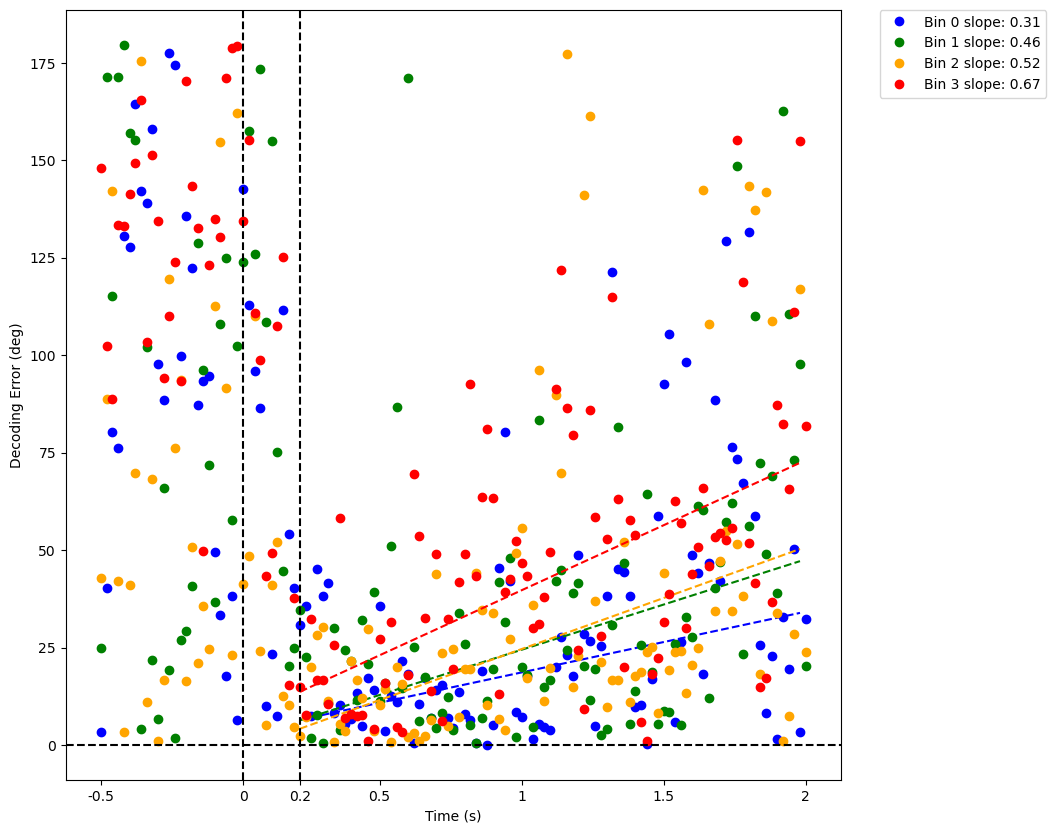

In [275]:
# Plot by decoding bin
from scipy.interpolate import interp1d
from scipy.ndimage import gaussian_filter1d
from sklearn.linear_model import TheilSenRegressor
# f, axs = plt.subplots(2, 2, figsize=(20, 10))
# axs = axs.ravel()
colFits = ['blue', 'green', 'orange', 'red']
colDots = ['blue', 'green', 'orange', 'red']
f = plt.figure(figsize=(10, 10))
for i in range(nBins):
    meanErr = np.abs(circmean(predBySubByBin[:, i, :], high=-180, low=180, axis=0))
    semErr = circstd(predBySubByBin[:, i, :], high=-180, low=180, axis=0) / np.sqrt(len(subList))

    xLin = np.arange(tidx_nb[2], tidx_nb[-1])
    xLinForFit = xLin - tidx_nb[2]
    yLin = meanErr[tidx_nb[2]:tidx_nb[-1]]

    # xLin = np.arange(tidx_nb[2], tidx_nb[-1])
    # yLin = meanErr[tidx_nb[2]:tidx_nb[-1]]
    # # Fit a linear polynomial to the data
    # coeffs = np.polyfit(xLin, yLin, 1)
    # yPred = coeffs[0] * xLin + coeffs[1]
    model = TheilSenRegressor(random_state=42, fit_intercept=True)
    model.fit(xLinForFit[:, np.newaxis], yLin)
    # coeffs = model.estimator_.coef_
    coeffs = model.coef_
    yPred = coeffs[0] * xLinForFit + model.intercept_

    plt.plot(xLin, yPred, '--', color=colFits[i])
    plt.plot(meanErr, 'o', color=colDots[i], label='Bin ' + str(i) + ' slope: ' + str(round(coeffs[0], 2)))
plt.axhline(0, color='k', linestyle='--')
plt.axvline(tidx_nb[1], color='k', linestyle='--')
plt.axvline(tidx_nb[2], color='k', linestyle='--')
plt.xlabel('Time (s)')
plt.ylabel('Decoding Error (deg)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.xticks(tidx_nb, time_nb)
plt.savefig('betaDecodErrWithTimeByBin_slope_withintercept.svg', dpi=300, format='svg')
# plt.show()
    # Generate a smooth curve using the polynomial coefficients
    # x = np.arange(len(meanErr))
    # yPred = coeffs[0] * x**2 + coeffs[1] * x + coeffs[2]
    # axs[i].plot(xLin, yPred, 'r--', label='Linear Fit')

    # axs[i].plot(meanErr, 'o', color='blue')
    # # x = np.arange(len(meanErr))
    # # xnew = np.linspace(0, len(meanErr)-1, 1000)
    # # fErr = interp1d(x, meanErr, kind='cubic', fill_value='extrapolate')(xnew)

    # # smoothedData = gaussian_filter1d(meanErr, sigma=1)
    # # smoothedErr = gaussian_filter1d(semErr, sigma=1)
    # # # tidx_nb = [np.argmin(np.abs(timesBeta - t)) for t in time_nb]
    # # # times_nb_new lol
    # # axs[i].fill_between(xnew, smoothedData - smoothedErr, smoothedData + smoothedErr, alpha=0.5)
    # # axs[i].plot(smoothedData, color='blue')
    # axs[i].axhline(0, color='k', linestyle='--')
    # axs[i].axvline(tidx_nb[1], color='k', linestyle='--')
    # axs[i].axvline(tidx_nb[2], color='k', linestyle='--')
    # axs[i].set_title('Bin ' + str(i) + ' slope: ' + str(round(coeffs[0], 2)))
    # axs[i].set_xlabel('Time (s)')
    # axs[i].set_ylabel('Decoding Error (deg)')
    # # axs[i].set_ylim([-180, 180])
    # axs[i].axhline(0, color='k', linestyle='--')
    # # axs[i].set_xticks(tidx_nb)
    # axs[i].set_xticks(tidx_nb, time_nb)

In [36]:
perfMat.shape

(1, 10000)

In [29]:
df_filtered[df_filtered['subjID'] == 1].shape

(159, 9)

## Trialwise decoding loo

In [2]:
import os, pickle, h5py, socket
import numpy as np
from scipy.io import loadmat
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from shutil import copyfile
from joblib import Parallel, delayed
from multiprocessing import Pool, cpu_count
import gc

def run_subject(subjID, bidsRoot, taskName, classifName, classifType, freqband, powOphase):
    subName = 'sub-%02d' % subjID
    print('Running classification for ' + subName)
    derivativesRoot = os.path.join(bidsRoot, 'derivatives', subName, 'meg')
    stimRoot = os.path.join(bidsRoot, subName, 'stimfiles')
    fNameRoot = subName + '_task-' + taskName
    if powOphase == 'power':
        TFR_fpath = os.path.join(derivativesRoot, fNameRoot + '_TFR_evoked_lineremoved.mat')
    else:
        TFR_fpath = os.path.join(derivativesRoot, fNameRoot + '_TFR_phase.mat')
    classifHolderRoot = os.path.join(derivativesRoot, 'decoding_trialwise')
    if not os.path.exists(classifHolderRoot):
        os.mkdir(classifHolderRoot)

    classifPath = os.path.join(classifHolderRoot, classifName)

    if os.path.exists(classifPath):
        # Load the classifier
        print('Loading existing classifier performance')
        with open(classifPath, 'rb') as f:
            classifData = pickle.load(f)
        trlWiseDecoding = classifData['trlWiseDecoding']
        trlWiseDecodingChance = classifData['trlWiseDecodingChance']
        performance = classifData['performance']
        yLabels = classifData['yLabels']
        times_crop = classifData['times_crop']
    
    return subjID, trlWiseDecoding, trlWiseDecodingChance, performance, yLabels, times_crop


def extractTGA(freqband):
    
    subList = [1, 2, 3, 4, 5, 6, 7, 9, 10, 12, 13, 15, 17, 
               18, 19, 23, 24, 25, 26, 27, 28, 29, 31, 32]
    # subList = [1, 2, 3, 4, 5, 6, 7, 9, 10, 12, 13, 15, 17]
    # subList = [1, 2, 3, 4, 5, 6, 7, 9]

    # freqband = 'broadband' # valid options: alpha, beta, broadband
    powOphase = 'power' # valid options: power, phase
    classifType = 'indivTargets' # valid options: hemifield, quadrant, locGroups, indivTargets
    classifName = 'Temporaclassif_' + classifType + '_' + freqband + '_loo.pkl'
    
    if freqband == 'broadband':
        ntimePts = 90
    else:
        ntimePts = 125
    trlDecodMat = np.empty((len(subList), 10000, ntimePts))
    trlDecodChanceMat = np.empty((len(subList), 10000, ntimePts))
    perfMat = np.empty((len(subList), 10000))
    yLabelMat = np.empty((len(subList), 10000))
    trlCounter = np.empty((len(subList)))

    bidsRoot = '/System/Volumes/Data/d/DATD/datd/MEG_MGS/MEG_BIDS'
   
    taskName = 'mgs'
    figDir = os.path.join(bidsRoot, 'derivatives', 'group_plots')
    if not os.path.exists(figDir):
        os.mkdir(figDir)

    # Run without parallelization
    for sIdx, subjID in enumerate(subList):
        res = run_subject(subjID, bidsRoot, taskName, classifName, classifType, freqband, powOphase)
        trlWiseDecoding, trlWiseDecodingChance, perfThisSub, yLabelsThisSub, times_crop = res[1], res[2], res[3], res[4], res[5]
        ntrlsThisSub = trlWiseDecoding.shape[0]
        trlCounter[sIdx] = ntrlsThisSub
        trlDecodMat[sIdx, :ntrlsThisSub, :] = trlWiseDecoding
        trlDecodChanceMat[sIdx, :ntrlsThisSub, :] = trlWiseDecodingChance
        perfMat[sIdx, :ntrlsThisSub] = perfThisSub
        yLabelMat[sIdx, :ntrlsThisSub] = yLabelsThisSub
    # Average the accuracy and f1score matrices
    # f1_matrix = np.nanmean(f1Mat, axis=0)
    # f1_chance_matrix = np.nanmean(f1ChanceMat, axis=0)

    # return f1_matrix, times_crop
    return trlDecodMat, trlDecodChanceMat, perfMat, times_crop, trlCounter, yLabelMat

In [4]:
# f1betaMat, trlDecodMat, perfMat, timesBeta, trlCounter, yLabelMat = extractTGA('beta')
# trlDecodMat, trlDecodChanceMat, perfMat, times_crop, trlCounter, yLabelMat = extractTGA('theta')

trlDecodMatTheta, trlDecodChanceMatTheta, perfMatTheta, timesTheta, trlCounterTheta, yLabelMatTheta = extractTGA('theta')
trlDecodMatAlpha, trlDecodChanceMatAlpha, perfMatAlpha, timesAlpha, trlCounterAlpha, yLabelMatAlpha = extractTGA('alpha')
trlDecodMatBeta, trlDecodChanceMatBeta, perfMatBeta, timesBeta, trlCounterBeta, yLabelMatBeta = extractTGA('beta')

Running classification for sub-01
Loading existing classifier performance
Running classification for sub-02
Loading existing classifier performance
Running classification for sub-03
Loading existing classifier performance
Running classification for sub-04
Loading existing classifier performance
Running classification for sub-05
Loading existing classifier performance
Running classification for sub-06
Loading existing classifier performance
Running classification for sub-07
Loading existing classifier performance
Running classification for sub-09
Loading existing classifier performance
Running classification for sub-10
Loading existing classifier performance
Running classification for sub-12
Loading existing classifier performance
Running classification for sub-13
Loading existing classifier performance
Running classification for sub-15
Loading existing classifier performance
Running classification for sub-17
Loading existing classifier performance
Running classification for sub-18
Load

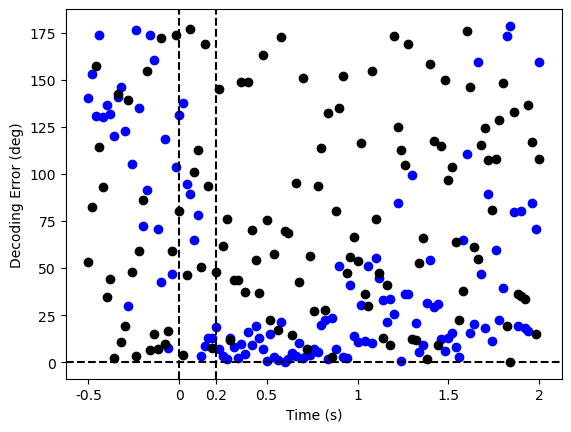

In [6]:
from scipy.stats import circmean, circstd
time_nb = [-0.5, 0, 0.2, 0.5, 1, 1.5, 2]
time_broad = [-0.1, 0, 0.2, 0.5, 1, 1.5]
tidx_nb = [np.argmin(np.abs(timesBeta - t)) for t in time_nb]
# meanErr = np.abs(circmean(predBySub, high=-180, low=180, axis=0))
# trlDecodMatBeta, trlDecodChanceMatBeta, perfMatBeta, timesBeta, trlCounterBeta, yLabelMatBeta
meanErr = np.abs(circmean(predBySub[2, :, :], high=-180, low=180, axis=0))
meanChanceErr = np.abs(circmean(predChanceBySub[2, :, :], high=-180, low=180, axis=0))

# semErr = circstd(predBySub, high=-180, low=180, axis=0) / np.sqrt(len(subList))
plt.figure()
# plt.plot(circmean(predBySub, high=-180, low=180, axis=0), 'o')
# plt.fill_between(1:length(timesBeta), meanErr - semErr, meanErr + semErr, alpha=0.5)
plt.plot(meanErr, 'o', color='blue')
plt.plot(meanChanceErr, 'o', color='black')

plt.axhline(0, color='k', linestyle='--')
plt.axvline(tidx_nb[1], color='k', linestyle='--')
plt.axvline(tidx_nb[2], color='k', linestyle='--')
plt.xlabel('Time (s)')
plt.ylabel('Decoding Error (deg)')
plt.xticks(tidx_nb, time_nb)
plt.savefig('/d/DATD/datd/MD_TMS_EEG/4YearTalkFigures/Chapter3/decodAbsErrorOverTime_goodAndChance.svg', dpi=300, format='svg')
plt.show()

In [5]:
from scipy.stats import circmean, circstd, circvar
time_epOnset = [-0.3, 0.1, 0.5, 1]
time_epOffset = [0, 0.3, 1, 1.5]
tidx_nb_epOnset = [np.argmin(np.abs(timesBeta - t)) for t in time_epOnset]
tidx_nb_epOffset = [np.argmin(np.abs(timesBeta - t)) for t in time_epOffset]

epochLabels = ['Fixation', 'StimOn', 'Early Delay', 'Late Delay']
behavMetric = 'error'  # valid options: reaction_time, velocity, error
subList = [1, 2, 3, 4, 5, 6, 7, 9, 10, 12, 13, 15, 17, 
               18, 19, 23, 24, 25, 26, 27, 28, 29, 31, 32]

nBins = 4
class_angles = np.array([0, 25, 50, 130, 155, 180, 205, 230, 310, 335])

predBySub = np.empty((3, len(subList), trlDecodMatBeta.shape[2]))
predBySubByBin = np.empty((3, len(subList), nBins, trlDecodMatBeta.shape[2]))
predChanceBySub = np.empty((3, len(subList), trlDecodMatBeta.shape[2]))
predChanceBySubByBin = np.empty((3, len(subList), nBins, trlDecodMatBeta.shape[2]))

for fIdx, freqband in enumerate(['theta', 'alpha', 'beta']):
    if freqband == 'theta':
        trlDecodMat = trlDecodMatTheta
        trlDecodChanceMat = trlDecodChanceMatTheta
        perfMat = perfMatTheta
        trlCounter = trlCounterTheta
        yLabelMat = yLabelMatTheta
    elif freqband == 'alpha':
        trlDecodMat = trlDecodMatAlpha
        trlDecodChanceMat = trlDecodChanceMatAlpha
        perfMat = perfMatAlpha
        trlCounter = trlCounterAlpha
        yLabelMat = yLabelMatAlpha
    else:
        trlDecodMat = trlDecodMatBeta
        trlDecodChanceMat = trlDecodChanceMatBeta
        perfMat = perfMatBeta
        trlCounter = trlCounterBeta
        yLabelMat = yLabelMatBeta
    for sIdx in range(len(subList)):
        nTrlsInitial = trlCounter[sIdx].astype(int)
        nTpoints = trlDecodMat.shape[-1]
        behavPerf = perfMat[sIdx, :nTrlsInitial]
        # Find trls with behavPerf > 0.01
        goodTrls = np.where(behavPerf > 0.01)[0]
        nTrls = len(goodTrls)
        # print('Subject %d: %d trials' % (sIdx, nTrls))
        behavPerfGood = behavPerf[goodTrls]
        trlDecodMatGood = trlDecodMat[sIdx, goodTrls, :]
        trlDecodChanceMatGood = trlDecodChanceMat[sIdx, goodTrls, :]
        yLabelMatGood = yLabelMat[sIdx, goodTrls]-1
        # Divide into quantiles
        bin_edges = np.percentile(behavPerfGood, np.linspace(0, 100, nBins+1))
        # bin_edges = np.concatenate(([np.min(behavPerfGood)], bin_edges, [np.max(behavPerfGood)]))
        print(bin_edges)
        prediction_error = np.empty((nTrls, nTpoints))
        prediction_errorChance = np.empty((nTrls, nTpoints))

        for trlIdx in range(nTrls):
            predicted_classes = trlDecodMatGood[trlIdx, :].astype(int)
            predictedChance_classes = trlDecodChanceMatGood[trlIdx, :].astype(int)
            # Get actual class for this trial
            actual_class = yLabelMatGood[trlIdx].astype(int)
            # print(predicted_classes, actual_class)
            # Convert to angles
            pred_angles = class_angles[predicted_classes]
            predChance_angles = class_angles[predictedChance_classes]
            actual_angle = class_angles[actual_class]
            
            # Calculate circular error
            ang_diff = pred_angles - actual_angle
            ang_diff = ((ang_diff + 180) % 360) - 180
            ang_diffChance = predChance_angles - actual_angle
            ang_diffChance = ((ang_diffChance + 180) % 360) - 180
            prediction_error[trlIdx, :] = ang_diff
            prediction_errorChance[trlIdx, :] = ang_diffChance
            predBySub[fIdx, sIdx, :] = circmean(prediction_error, high=-180, low=180, axis=0)
            predChanceBySub[fIdx, sIdx, :] = circmean(prediction_errorChance, high=-180, low=180, axis=0)

        # Compute mean error by bin for each trial
        for binIdx in range(nBins):
            bin_mask = (behavPerfGood >= bin_edges[binIdx]) & (behavPerfGood < bin_edges[binIdx+1])
            # print(binIdx,     sum(bin_mask ))
            predBySubByBin[fIdx, sIdx, binIdx, :] = circmean(prediction_error[bin_mask, :], high=-180, low=180, axis=0)
            predChanceBySubByBin[fIdx, sIdx, binIdx, :] = circmean(prediction_errorChance[bin_mask, :], high=-180, low=180, axis=0)

[0.29903499 0.91062028 1.21112744 1.69616787 3.33791481]
[ 0.19381738  0.69014915  1.10911052  1.70397184 13.66206339]
[ 0.33861393  1.45363794  2.35839814  3.58113719 11.85248919]
[0.03746299 0.90637127 1.59171856 3.00309641 7.96229038]
[0.12036048 1.14605871 1.70615909 2.60766131 4.97446024]
[ 0.01463303  1.35239618  2.19079011  3.19877017 10.17083758]
[ 0.03874919  1.47872948  2.240853    3.32205562 11.29334635]
[ 0.01377367  1.08182461  1.82833945  2.97181708 11.00355306]
[ 0.03301134  0.84491947  1.33824838  2.08841041 11.033378  ]
[ 0.01287765  1.94322742  3.59220286  5.14806394 10.9705178 ]
[0.03164868 1.16915684 1.72389479 2.72964196 7.61431993]
[0.02366481 0.83948411 1.31139914 1.9359802  4.41317853]
[0.1066485  1.18283192 1.67351258 2.46933897 7.3743259 ]
[ 0.04051926  1.31661118  2.02591503  3.05542377 20.62512379]
[0.0305036  0.83485575 1.07139932 1.56110933 4.12552675]
[0.17952354 1.01319654 1.54346884 2.14515421 4.51687342]
[0.29214457 1.27236677 1.89031393 2.65091836 9.6

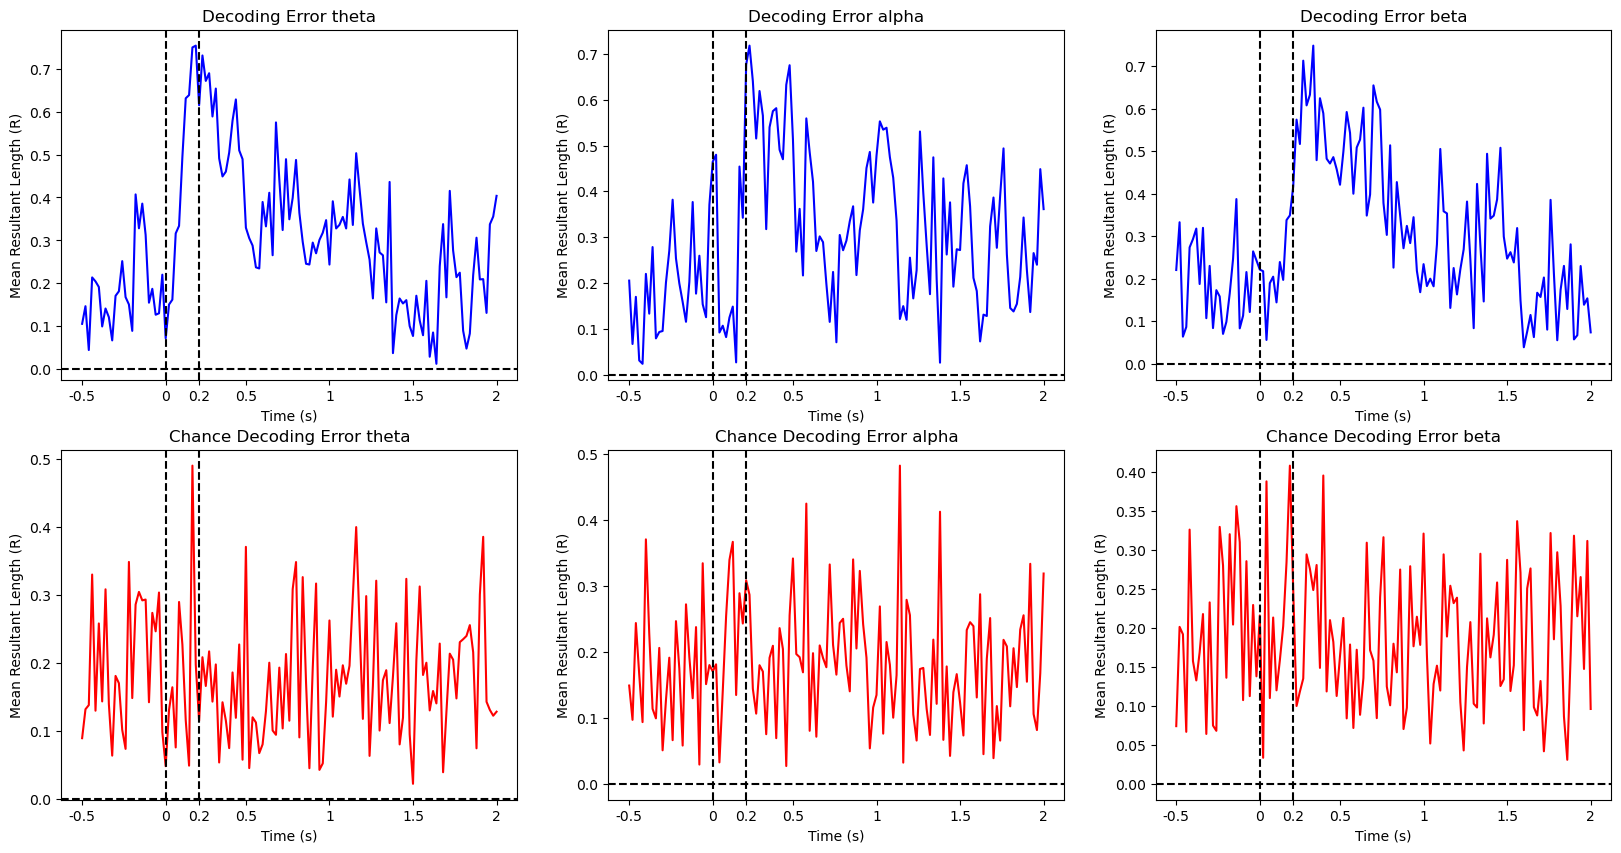

In [255]:
time_nb = [-0.5, 0, 0.2, 0.5, 1, 1.5, 2]
time_broad = [-0.1, 0, 0.2, 0.5, 1, 1.5]
tidx_nb = [np.argmin(np.abs(timesBeta - t)) for t in time_nb]
meanErr = circmean(predBySub, high=-180, low=180, axis=0)
semErr = circstd(predBySub, high=-180, low=180, axis=0) #/ np.sqrt(len(subList))
f, axs = plt.subplots(2, 3, figsize=(20, 10))
for fIdx, freqband in enumerate(['theta', 'alpha', 'beta']):
    predByFreq = predBySub[fIdx, :, :]
    predByFreqChance = predChanceBySub[fIdx, :, :]
    meanErr = 1-circvar(predByFreq, high=-180, low=180, axis=0)
    meanErrChance = 1-circvar(predByFreqChance, high=-180, low=180, axis=0)
    semErr = circvar(predByFreq, high=-180, low=180, axis=0) / np.sqrt(len(subList))
    semErrChance = circstd(predByFreqChance, high=-180, low=180, axis=0) / np.sqrt(len(subList))
    axs[0,fIdx].plot(meanErr, '-', color='blue')
    # axs[0,fIdx].fill_between(np.arange(len(timesBeta)), meanErr - semErr, meanErr + semErr, alpha=0.5)
    axs[1,fIdx].plot(meanErrChance, '-', color='red')
    # axs[1,fIdx].fill_between(np.arange(len(timesBeta)), meanErrChance - semErrChance, meanErrChance + semErrChance, alpha=0.5)
    axs[0,fIdx].axhline(0, color='k', linestyle='--')
    axs[1,fIdx].axhline(0, color='k', linestyle='--')
    axs[0,fIdx].axvline(tidx_nb[1], color='k', linestyle='--')
    axs[0,fIdx].axvline(tidx_nb[2], color='k', linestyle='--')
    axs[1,fIdx].axvline(tidx_nb[1], color='k', linestyle='--')
    axs[1,fIdx].axvline(tidx_nb[2], color='k', linestyle='--')
    axs[0,fIdx].set_title('Decoding Error ' + freqband)
    axs[1,fIdx].set_title('Chance Decoding Error ' + freqband)
    axs[0,fIdx].set_xlabel('Time (s)')
    axs[1,fIdx].set_xlabel('Time (s)')
    # axs[0,fIdx].set_ylabel('Decoding Error (deg)')
    # axs[1,fIdx].set_ylabel('Decoding Error (deg)')
    axs[0,fIdx].set_ylabel('Mean Resultant Length (R)')
    axs[1,fIdx].set_ylabel('Mean Resultant Length (R)')
    axs[0,fIdx].set_xticks(tidx_nb, time_nb)
    axs[1,fIdx].set_xticks(tidx_nb, time_nb)
plt.show()

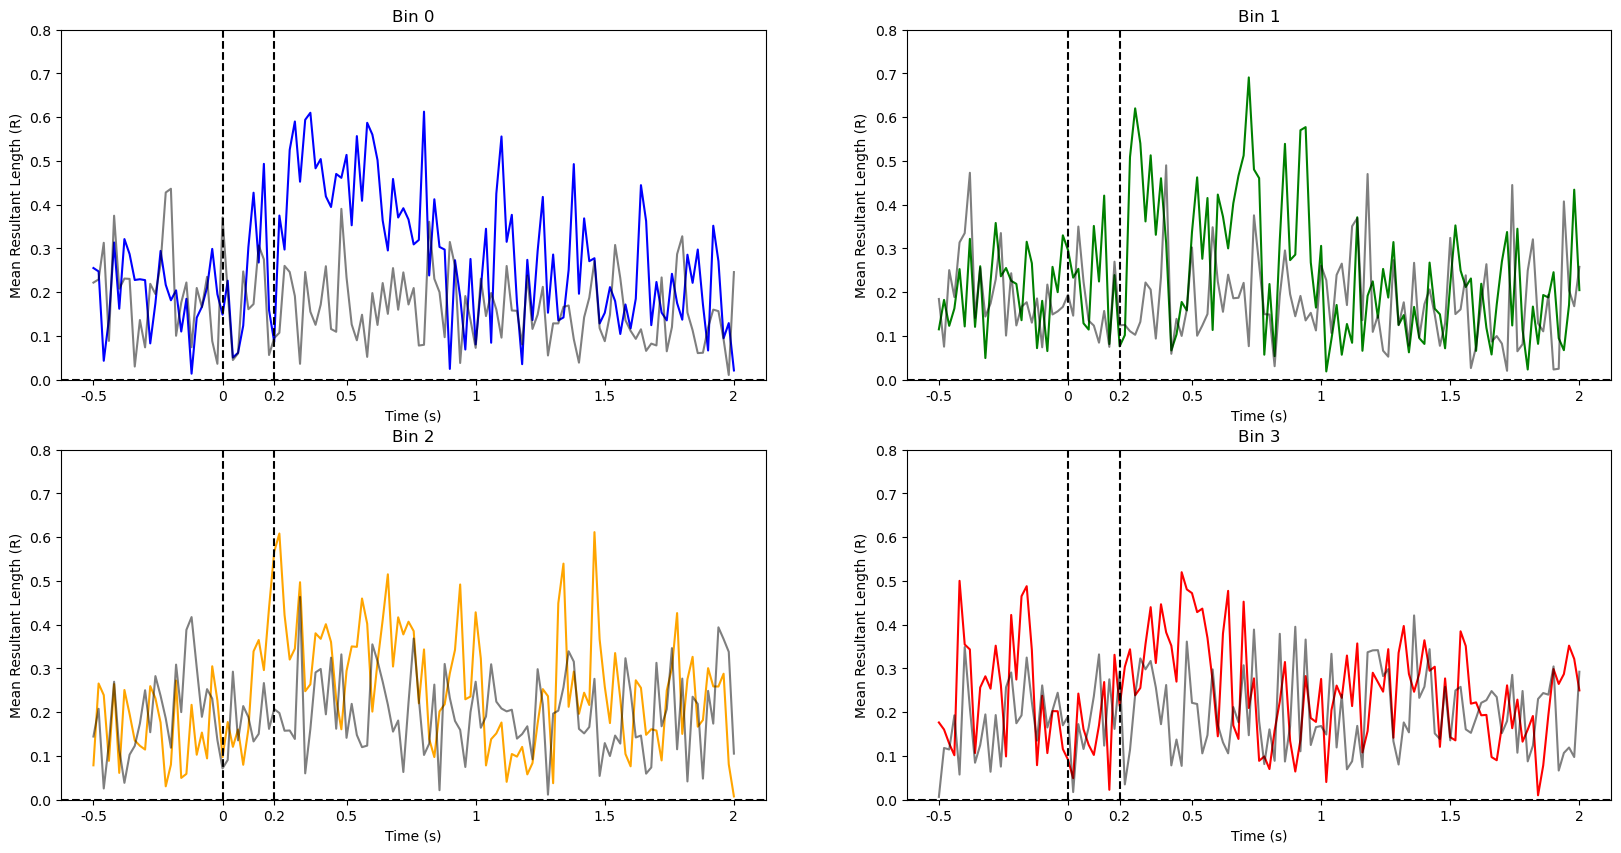

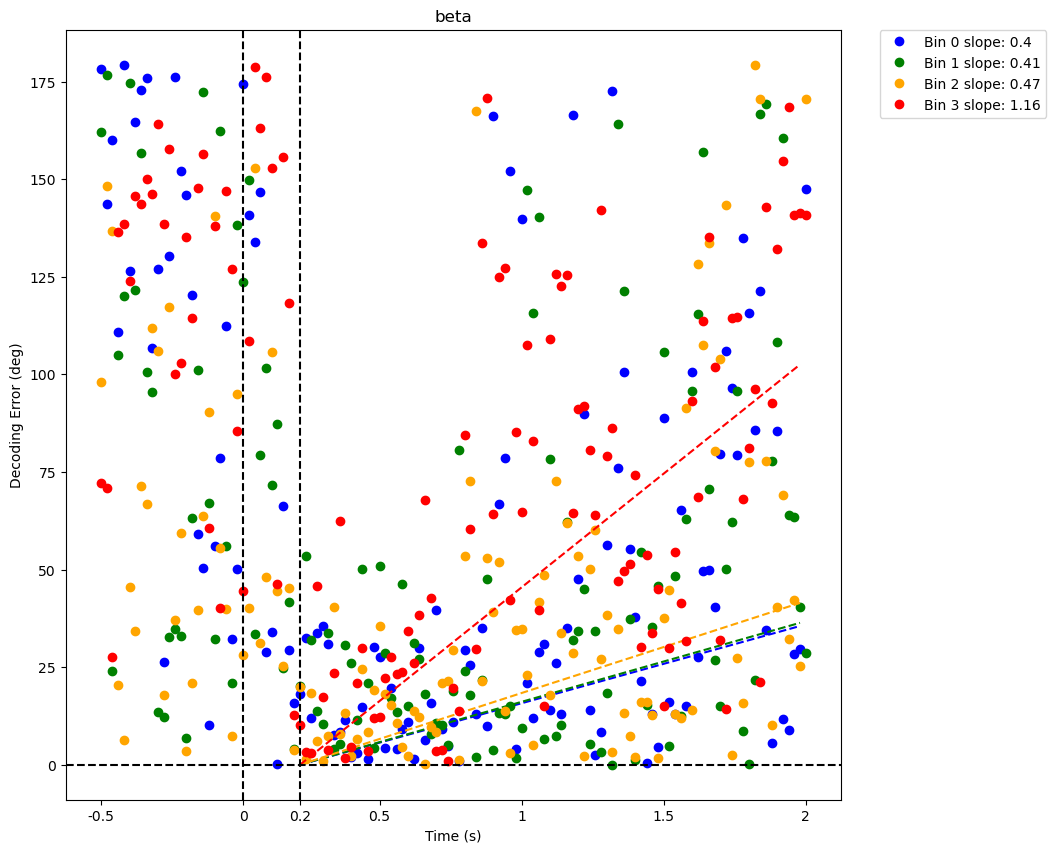

In [266]:
# Plot by decoding bin
from sklearn.linear_model import LinearRegression, RANSACRegressor, TheilSenRegressor
# f, axs = plt.subplots(2, 2, figsize=(20, 10))
# axs = axs.ravel()
colFits = ['blue', 'green', 'orange', 'red']
colDots = ['blue', 'green', 'orange', 'red']
# f = plt.figure(figsize=(10, 10))
f, axs = plt.subplots(2, 2, figsize=(20, 10))
axs = axs.ravel()
for i in range(nBins):
    meanErr = 1-circvar(predBySubByBin[2, :, i, :], high=-180, low=180, axis=0)
    meanErrChance = 1-circvar(predChanceBySubByBin[2, :, i, :], high=-180, low=180, axis=0)
    # meanErrSmoothed = gaussian_filter1d(meanErr, sigma=0.7)
    # meanErrChanceSmoothed = gaussian_filter1d(meanErrChance, sigma=0.7)
    # xLin = np.arange(tidx_nb[2], tidx_nb[-1])
    # yLin = meanErr[tidx_nb[2]:tidx_nb[-1]]
    # # Fit a linear polynomial to the data
    # model = LinearRegression(fit_intercept=False)
    # model.fit(xLin[:, np.newaxis], yLin)
    # coeffs = model.coef_
    # yPred = coeffs[0] * xLin

    # plt.plot(xLin, yPred, '--', color=colFits[i])
    # plt.plot(meanErr, 'o', color=colDots[i], label='Bin ' + str(i))
    # plt.plot(meanErrChance, 'o', color='black', label='Bin ' + str(i) + ' Chance', alpha=0.5)
    axs[i].plot(meanErr, '-', color=colDots[i])
    axs[i].plot(meanErrChance, '-', color='black', alpha=0.5)
    axs[i].axhline(0, color='k', linestyle='--')
    axs[i].axvline(tidx_nb[1], color='k', linestyle='--')
    axs[i].axvline(tidx_nb[2], color='k', linestyle='--')
    axs[i].set_xlabel('Time (s)')
    axs[i].set_ylabel('Mean Resultant Length (R)')
    axs[i].set_title('Bin ' + str(i))
    axs[i].set_xticks(tidx_nb, time_nb)
    axs[i].set_ylim([0, 0.8])
plt.show()
# plt.axhline(0, color='k', linestyle='--')
# plt.axvline(tidx_nb[1], color='k', linestyle='--')
# plt.axvline(tidx_nb[2], color='k', linestyle='--')
# plt.xlabel('Time (s)')
# plt.ylabel('Decoding Error (deg)')
# plt.legend()
# plt.xticks(tidx_nb, time_nb)
# plt.title('beta')
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
# plt.show()


# Plot instead mean resultant length
f = plt.figure(figsize=(10, 10))
for i in range(nBins):
    meanErr = np.abs(circmean(predBySubByBin[2, :, i, :], high=-180, low=180, axis=0))
    xLin = np.arange(tidx_nb[2], tidx_nb[-1])
    xLinForFit = xLin - tidx_nb[2]
    yLin = meanErr[tidx_nb[2]:tidx_nb[-1]]
    # Fit a linear polynomial to the data
    # model = LinearRegression(fit_intercept=False)
    # model = RANSACRegressor(LinearRegression(fit_intercept=False), random_state=42)
    model = TheilSenRegressor(random_state=42)
    model.fit(xLinForFit[:, np.newaxis], yLin)
    # coeffs = model.estimator_.coef_
    coeffs = model.coef_
    yPred = coeffs[0] * xLinForFit

    plt.plot(xLin, yPred, '--', color=colFits[i])
    plt.plot(meanErr, 'o', color=colDots[i], label='Bin ' + str(i) + ' slope: ' + str(round(coeffs[0], 2)))
plt.axhline(0, color='k', linestyle='--')
plt.axvline(tidx_nb[1], color='k', linestyle='--')
plt.axvline(tidx_nb[2], color='k', linestyle='--')
plt.xlabel('Time (s)')
plt.ylabel('Decoding Error (deg)')
plt.legend()
plt.xticks(tidx_nb, time_nb)
plt.title('beta')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.show()

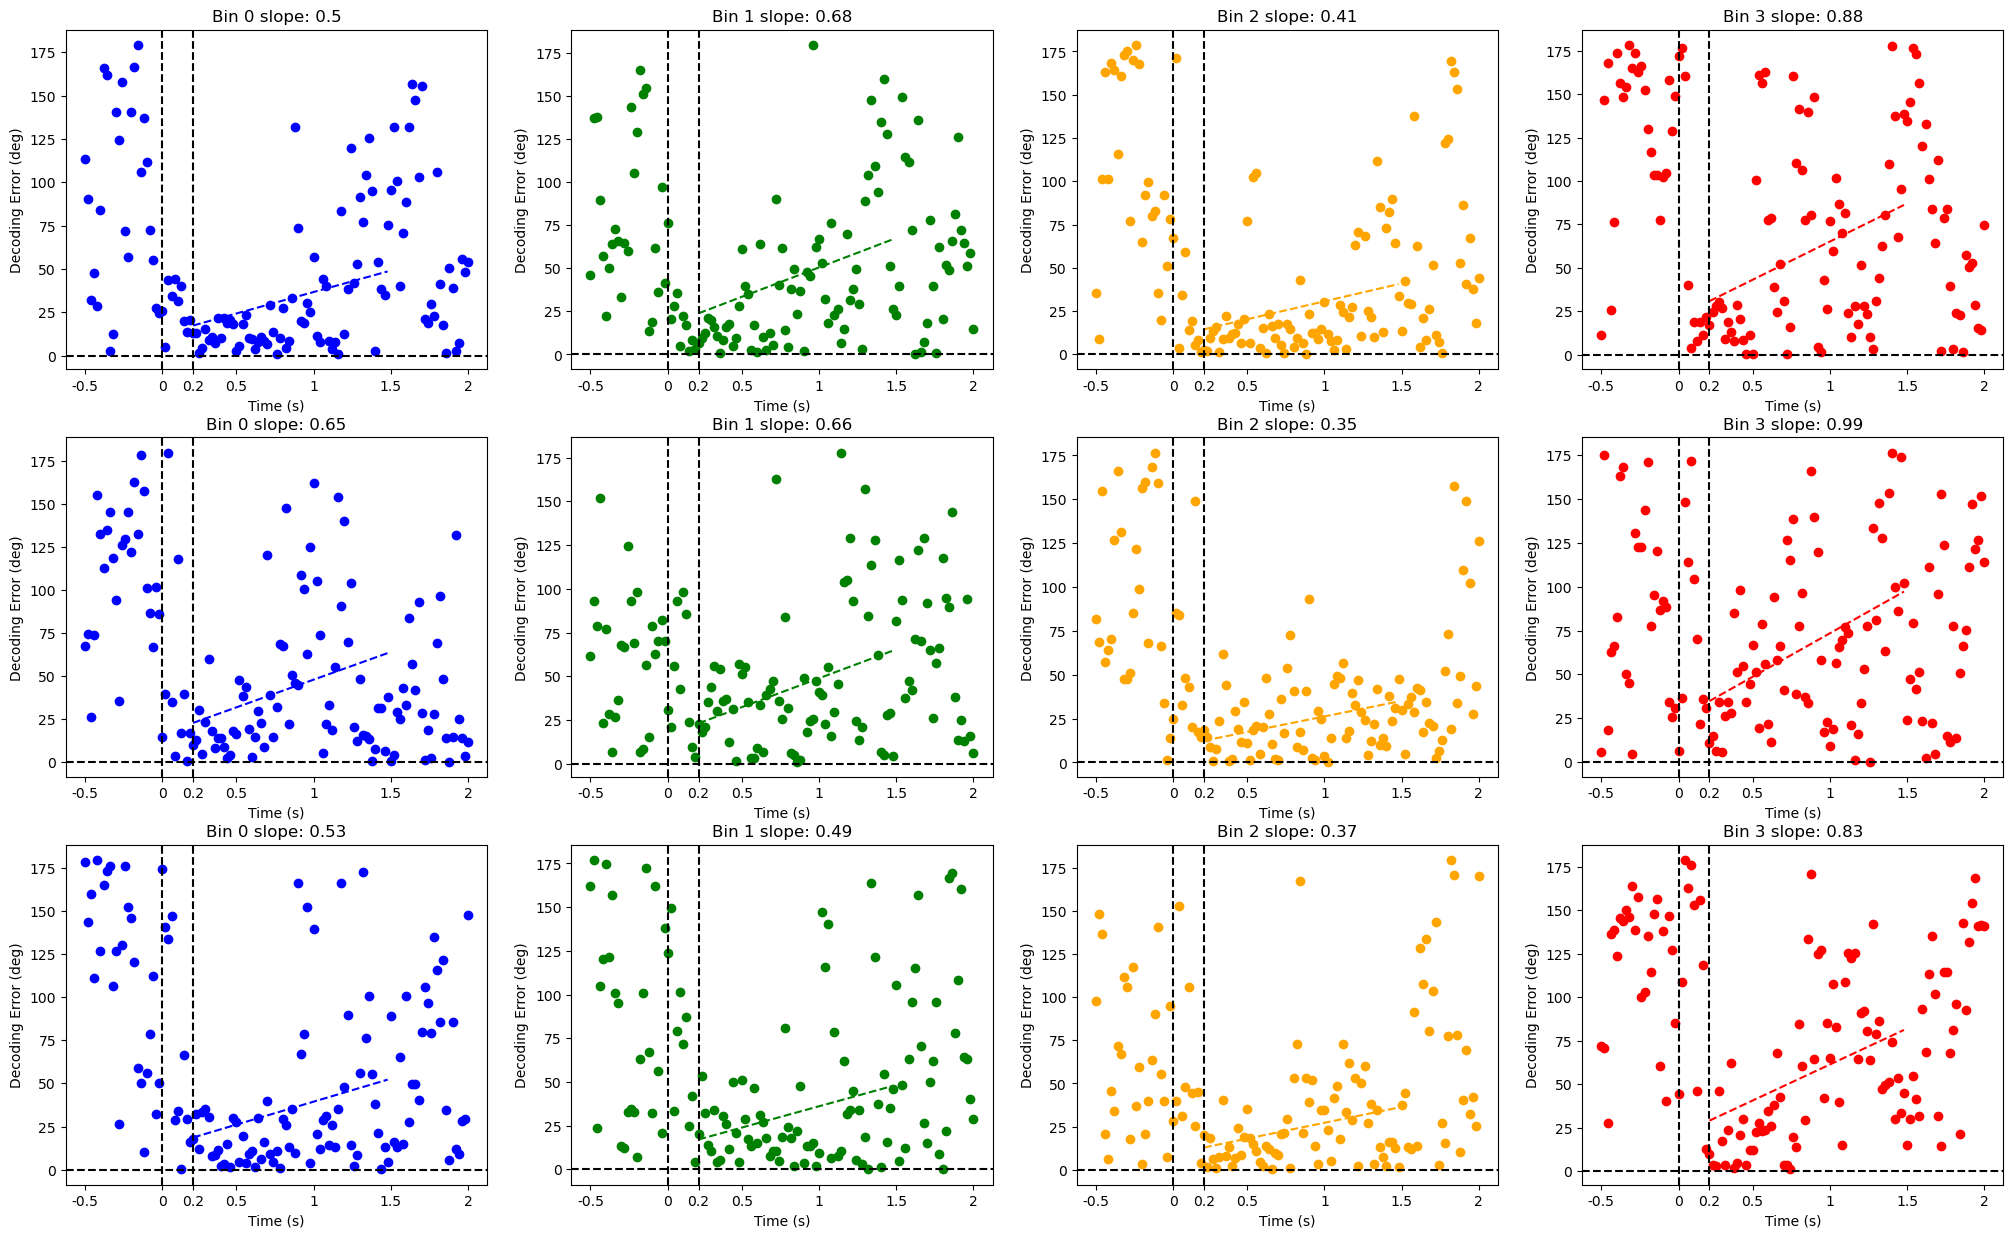

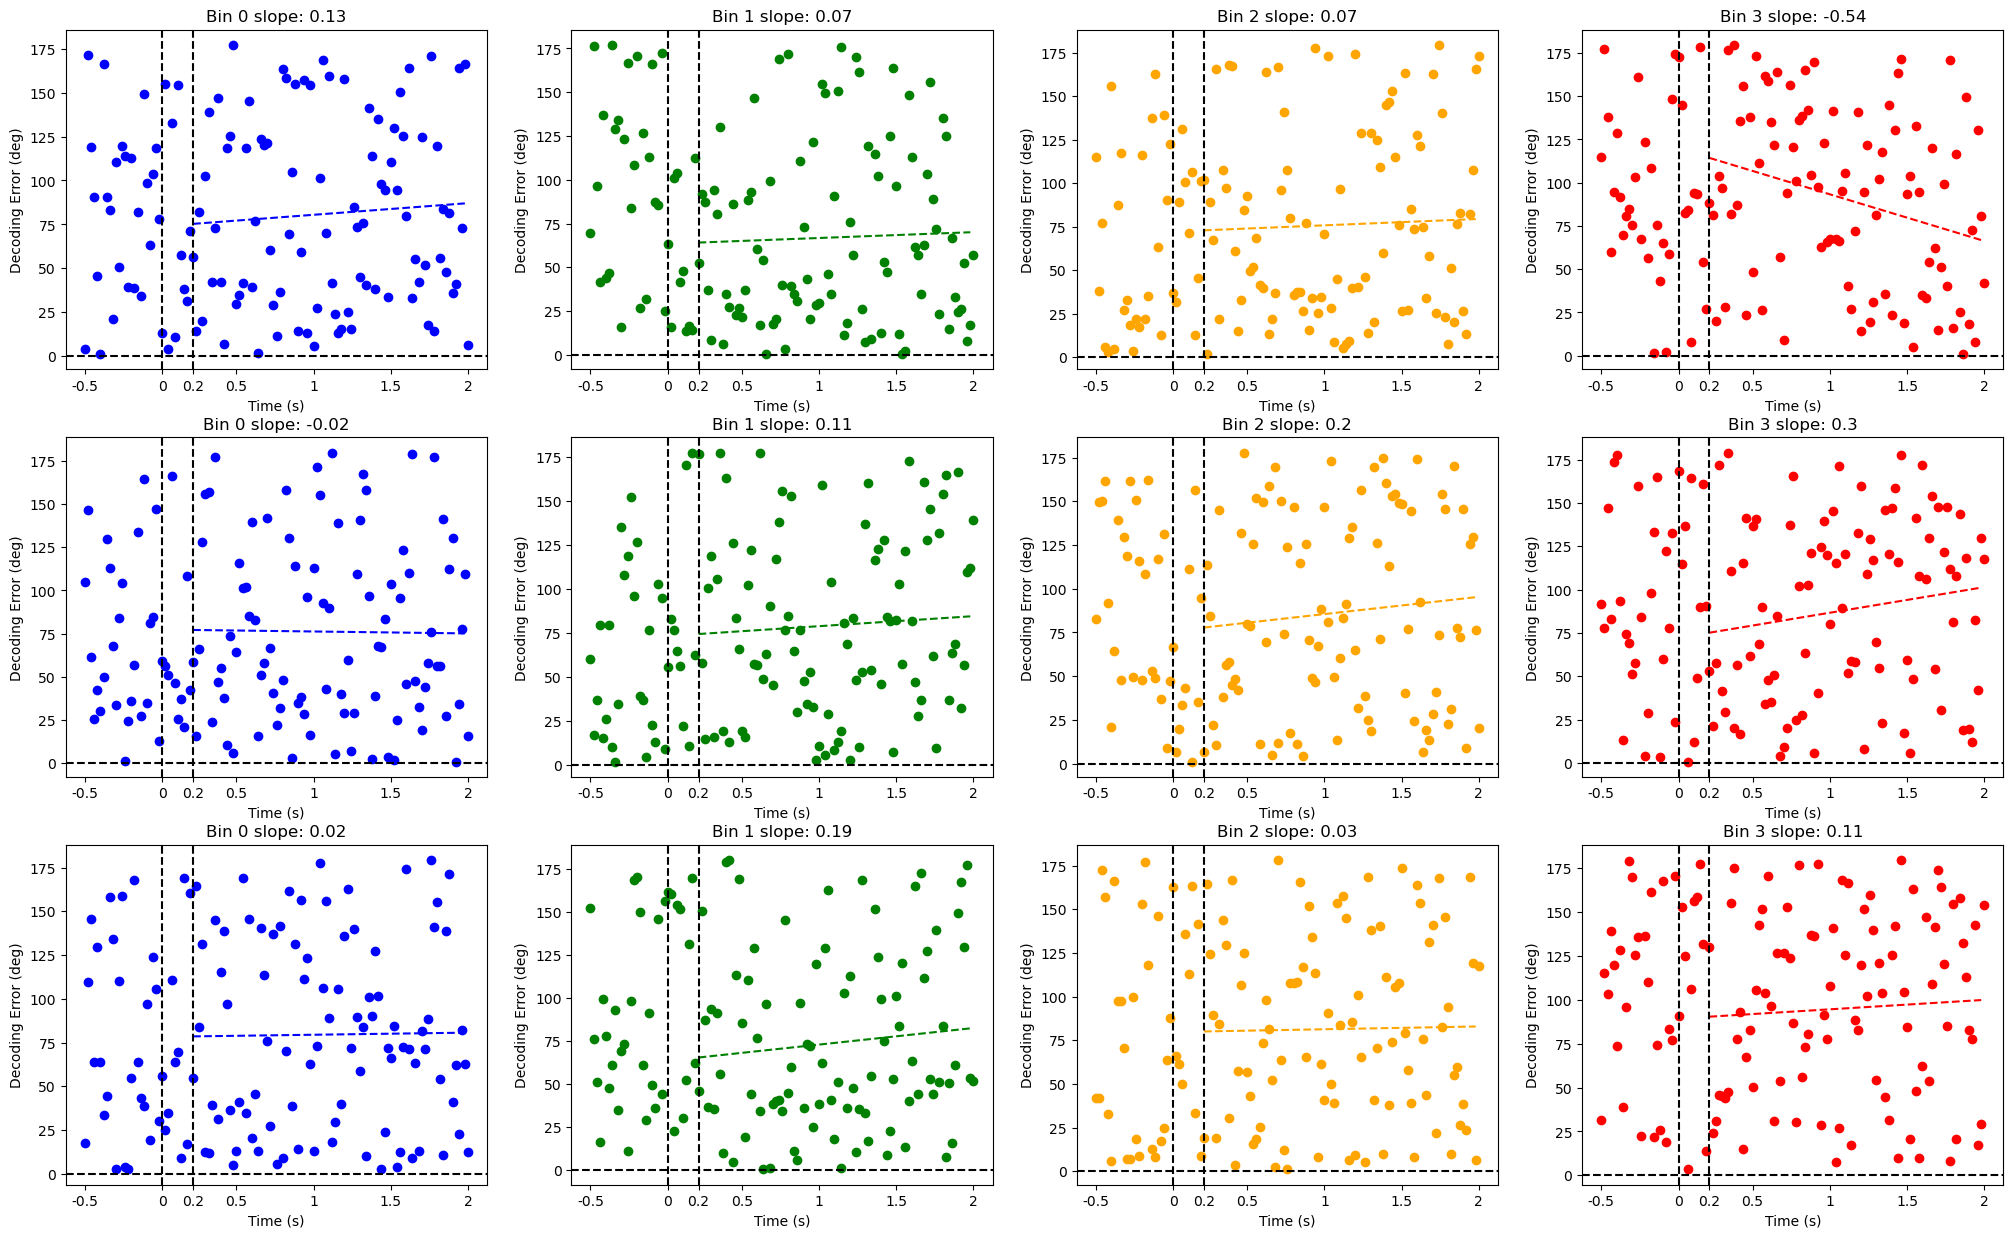

In [ ]:
# Plot by decoding bin
from scipy.interpolate import interp1d
from scipy.ndimage import gaussian_filter1d
# f, axs = plt.subplots(2, 2, figsize=(20, 10))
# axs = axs.ravel()
colFits = ['blue', 'green', 'orange', 'red']
colDots = ['blue', 'green', 'orange', 'red']

# Plot by decoding bin for each frequency for non-chance
f, axs = plt.subplots(3, 4, figsize=(25, 15))
for fIdx, freqband in enumerate(['theta', 'alpha', 'beta']):
    for i in range(nBins):
        # meanErr = np.abs(circmean(predBySubByBin[:, i, :], high=-180, low=180, axis=0))
        meanErr = np.abs(circmean(predBySubByBin[fIdx, :, i, :], high=-180, low=180, axis=0))
        # semErr = circstd(predBySubByBin[:, i, :], high=-180, low=180, axis=0) / np.sqrt(len(subList))

        xLin = np.arange(tidx_nb[2], tidx_nb[-2])
        yLin = meanErr[tidx_nb[2]:tidx_nb[-2]]
        # Fit a linear polynomial to the data
        # coeffs = np.polyfit(xLin, yLin, 1)
        # yPred = coeffs[0] * xLin #+ coeffs[1]
        # Fit another linear regression with intercept 0
        # coeffs, _, _, _ = np.linalg.lstsq(xLin[:, np.newaxis], yLin, rcond=None)
        # print(coeffs)
        # yPred = coeffs[0] * xLin
        model = LinearRegression(fit_intercept=False)
        model.fit(xLin[:, np.newaxis], yLin)
        coeffs = model.coef_
        yPred = coeffs[0] * xLin

        axs[fIdx, i].plot(xLin, yPred, '--', color=colFits[i])
        axs[fIdx, i].plot(meanErr, 'o', color=colDots[i], label='Bin ' + str(i))
        axs[fIdx, i].axhline(0, color='k', linestyle='--')
        axs[fIdx, i].axvline(tidx_nb[1], color='k', linestyle='--')
        axs[fIdx, i].axvline(tidx_nb[2], color='k', linestyle='--')
        axs[fIdx, i].set_xlabel('Time (s)')
        axs[fIdx, i].set_ylabel('Decoding Error (deg)')
        axs[fIdx, i].set_title('Bin ' + str(i) + ' slope: ' + str(round(coeffs[0], 2)))
        axs[fIdx, i].set_xticks(tidx_nb, time_nb)
        # axs[fIdx, i].set_xlim([-0.5, 1.7])
plt.show()

# Plot by decoding bin for each frequency for chance
# Plot by decoding bin for each frequency for non-chance
f, axs = plt.subplots(3, 4, figsize=(25, 15))
for fIdx, freqband in enumerate(['theta', 'alpha', 'beta']):
    for i in range(nBins):
        # meanErr = np.abs(circmean(predBySubByBin[:, i, :], high=-180, low=180, axis=0))
        meanErr = np.abs(circmean(predChanceBySubByBin[fIdx, :, i, :], high=-180, low=180, axis=0))
        # semErr = circstd(predBySubByBin[:, i, :], high=-180, low=180, axis=0) / np.sqrt(len(subList))

        xLin = np.arange(tidx_nb[2], tidx_nb[-1])
        yLin = meanErr[tidx_nb[2]:tidx_nb[-1]]
        # Fit a linear polynomial to the data
        coeffs = np.polyfit(xLin, yLin, 1)
        yPred = coeffs[0] * xLin + coeffs[1]

        axs[fIdx, i].plot(xLin, yPred, '--', color=colFits[i])
        axs[fIdx, i].plot(meanErr, 'o', color=colDots[i], label='Bin ' + str(i))
        axs[fIdx, i].axhline(0, color='k', linestyle='--')
        axs[fIdx, i].axvline(tidx_nb[1], color='k', linestyle='--')
        axs[fIdx, i].axvline(tidx_nb[2], color='k', linestyle='--')
        axs[fIdx, i].set_xlabel('Time (s)')
        axs[fIdx, i].set_ylabel('Decoding Error (deg)')
        axs[fIdx, i].set_title('Bin ' + str(i) + ' slope: ' + str(round(coeffs[0], 2)))
        axs[fIdx, i].set_xticks(tidx_nb, time_nb)
plt.show()